### **0.1. Importing packages and functions**

In [46]:
import dask
#for ignoring stuff
import warnings
warnings.simplefilter("ignore")
# for skiping running a certain cell
from IPython.core.magic import register_cell_magic

@register_cell_magic
def comment(line, cell):
    return

# for getting ot the right directory
import sys

#importing the necessary functions
sys.path.append("/nird/home/chrikap/Atmosphere_Ocean_Interactions_PhD/functions/nird_functions")
from common_NIRD_functions import *

### **0.2. For the tas vs latitude plots**

In [2]:
time_windows = [(0, 30), (120, 150), (270, 300), (470, 500), (570, 600),
                (870, 900), (970, 999)]
colors = plt.cm.rainbow(np.linspace(0, 1, len(time_windows)))

# **A. NorESM2-LM**

## **1. Processing the data**

### **1.1 Importing tas from NIRD**

In [3]:
experiments = ['piControl', 'abrupt-4xCO2']

tas_exp_noresm2 = []

for experiment in experiments:
            
    folder_path = f'/projects/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/{experiment}/r1i1p1f1/Amon/tas/gn/latest/'

    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks={'time': 10}) for file_name in file_names if file_name.endswith('.nc')]
    
    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')
    ds = merged_datasets.isel(time=slice(0, 500*12))

    yearly_tas = yearly_avg(ds['tas'])
    
    tas_exp_noresm2.append(yearly_tas)

lon_noresm2 = ds['lon'].values     
lat_noresm2 = ds['lat'].values

### **1.2. Turning K--> C and selecting the desired timeslices**

In [4]:
tas_exp_noresm2_piControl = tas_exp_noresm2[0]-273.15
tas_exp_noresm2_x4CO2 = tas_exp_noresm2[1]-273.15

tas_noresm2_0_30 = (tas_exp_noresm2_x4CO2.isel(year = slice(0, 30))).mean(dim='year')
tas_noresm2_120_150 = (tas_exp_noresm2_x4CO2.isel(year = slice(120, 150))).mean(dim='year')
tas_noresm2_470_500 = (tas_exp_noresm2_x4CO2.isel(year = slice(470,500))).mean(dim='year')

tas_noresm2_piControl = (tas_exp_noresm2_piControl.isel(year = slice(0, 30))).mean(dim='year')

## **2. Zonal plots of Air temperature and anomalies vs latitude**

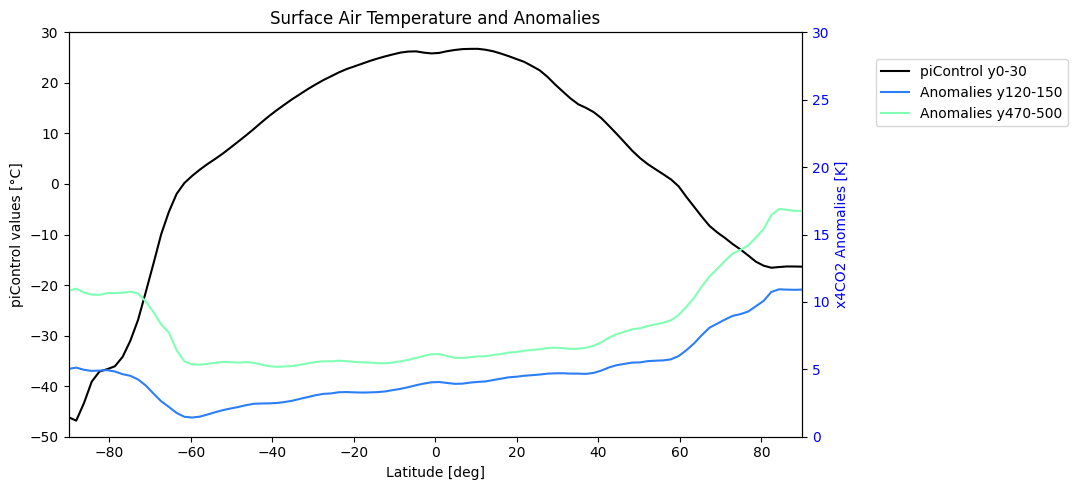

In [5]:
# 1. piControl & anomalies

fig, ax = plt.subplots(figsize=(11,5))

# --- Main axis (absolute temperature) ---
ax.plot(lat_noresm2, tas_noresm2_piControl.mean(dim='lon'),
        color='black', label='piControl y0-30')
ax.set_xlabel('Latitude [deg]')
ax.set_ylabel('piControl values [°C]', color='black')
ax.tick_params(axis='y', labelcolor='black')

# --- Twin axis for anomalies ---
ax2 = ax.twinx()

ax2.plot(lat_noresm2, tas_noresm2_120_150.mean(dim='lon') - tas_noresm2_piControl.mean(dim='lon'),
         color=colors[1], label='Anomalies y120-150')
ax2.plot(lat_noresm2, tas_noresm2_470_500.mean(dim='lon') - tas_noresm2_piControl.mean(dim='lon'),
         color=colors[3], label='Anomalies y470-500')

ax2.set_ylabel('x4CO2 Anomalies [K]', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# --- Combine legends from both axes ---
# --- Combine legends from both axes ---
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# Legend outside the plot
ax.legend(lines + lines2, labels + labels2,
          loc='center left', bbox_to_anchor=(1.1, 0.85), borderaxespad=0.)
ax.set_ylim(-50, 30)
ax2.set_ylim(0, 30)
ax.set_xlim(-90, 90)

plt.title('Surface Air Temperature and Anomalies')
plt.tight_layout()
plt.show()

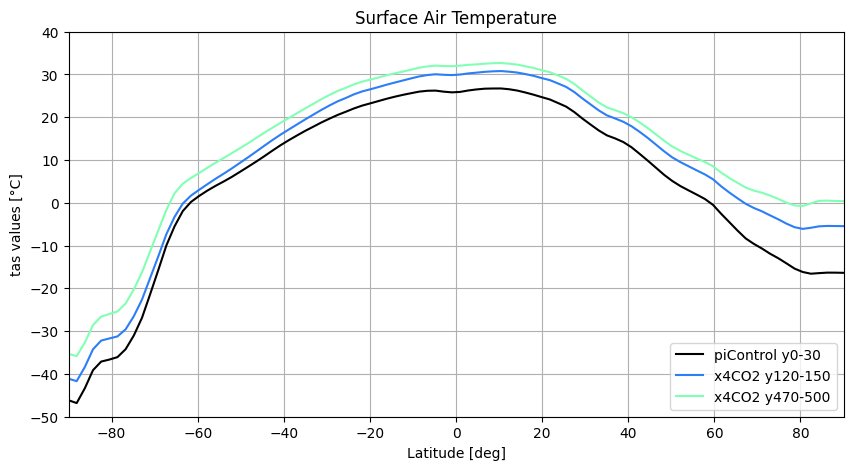

In [6]:
# 2. piControl & x4CO2

fig, ax = plt.subplots(figsize=(10,5))

# --- Main axis (absolute temperature) ---
plt.plot(lat_noresm2, tas_noresm2_piControl.mean(dim='lon'),
        color='black', label='piControl y0-30')

plt.plot(lat_noresm2, tas_noresm2_120_150.mean(dim='lon'),
         color=colors[1], label='x4CO2 y120-150')
plt.plot(lat_noresm2, tas_noresm2_470_500.mean(dim='lon'),
         color=colors[3], label='x4CO2 y470-500')

plt.xlabel('Latitude [deg]')
plt.ylabel('tas values [°C]', color='black')
plt.xlim(-90, 90)
plt.ylim(-50, 40)

plt.legend(loc = 'lower right')
plt.title('Surface Air Temperature')
plt.grid()
plt.show()

## **3. tas timeseries for piControl, x4CO2 and Anomalies (rolling average)**

### **3.1. Getting tas hemispherically and globally averaged**

In [7]:
tas_pi_noresm2_gl = (areaavg(tas_exp_noresm2[0].to_dataset(name = "restom"), "restom")-273.15).values
tas_pi_noresm2_nh = (areaavg((tas_exp_noresm2[0].sel(lat=slice(0,None))).to_dataset(name = "restom"), "restom")-273.15).values
tas_pi_noresm2_sh = (areaavg((tas_exp_noresm2[0].sel(lat=slice(None,0))).to_dataset(name = "restom"), "restom")-273.15).values

tas_x4CO2_noresm2_gl = (areaavg(tas_exp_noresm2[1].to_dataset(name = "restom"), "restom")-273.15).values
tas_x4CO2_noresm2_nh = (areaavg((tas_exp_noresm2[1].sel(lat=slice(0,None))).to_dataset(name = "restom"), "restom")-273.15).values
tas_x4CO2_noresm2_sh = (areaavg((tas_exp_noresm2[1].sel(lat=slice(None,0))).to_dataset(name = "restom"), "restom")-273.15).values

anom_tas_noresm_gl = np.array([tas_x4CO2_noresm2_gl[i]-np.mean(tas_pi_noresm2_gl) for i in range(0, 500)])
anom_tas_noresm_nh = np.array([tas_x4CO2_noresm2_nh[i]-np.mean(tas_pi_noresm2_nh) for i in range(0, 500)])
anom_tas_noresm_sh = np.array([tas_x4CO2_noresm2_sh[i]-np.mean(tas_pi_noresm2_sh) for i in range(0, 500)])

### **3.2. Applying a rolling average**

In [8]:
# 1. Using the rolling_average_ts function
roll_tas_pi_noresm2_gl = rolling_average_ts(tas_pi_noresm2_gl, 11)
roll_tas_pi_noresm2_nh = rolling_average_ts(tas_pi_noresm2_nh, 11)
roll_tas_pi_noresm2_sh = rolling_average_ts(tas_pi_noresm2_sh, 11)

roll_tas_x4_noresm2_gl = rolling_average_ts(tas_x4CO2_noresm2_gl, 11)
roll_tas_x4_noresm2_nh = rolling_average_ts(tas_x4CO2_noresm2_nh, 11)
roll_tas_x4_noresm2_sh = rolling_average_ts(tas_x4CO2_noresm2_sh, 11)

roll_anom_tas_gl_noresm2 = rolling_average_ts(anom_tas_noresm_gl, 11)
roll_anom_tas_nh_noresm2 = rolling_average_ts(anom_tas_noresm_nh, 11)
roll_anom_tas_sh_noresm2 = rolling_average_ts(anom_tas_noresm_sh, 11)

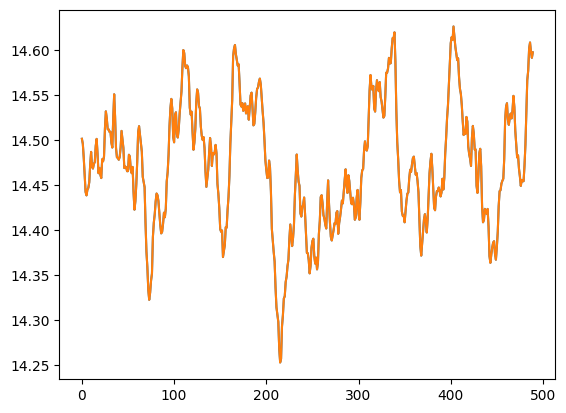

In [9]:
#testing the default rolling function
# we must use convolve for ipsl and cesm2, since it's faster and both models have almost double the data. 
    
test_roll_nor = convolve_f(tas_pi_noresm2_gl, 11)
plt.plot(test_roll_nor)
plt.plot(roll_tas_pi_noresm2_gl)

### **3.3. Plotting**

We center the plots in the time period by leaving 5 years from the beginning and 5 years in the end (centering of the 11y rolling mean)

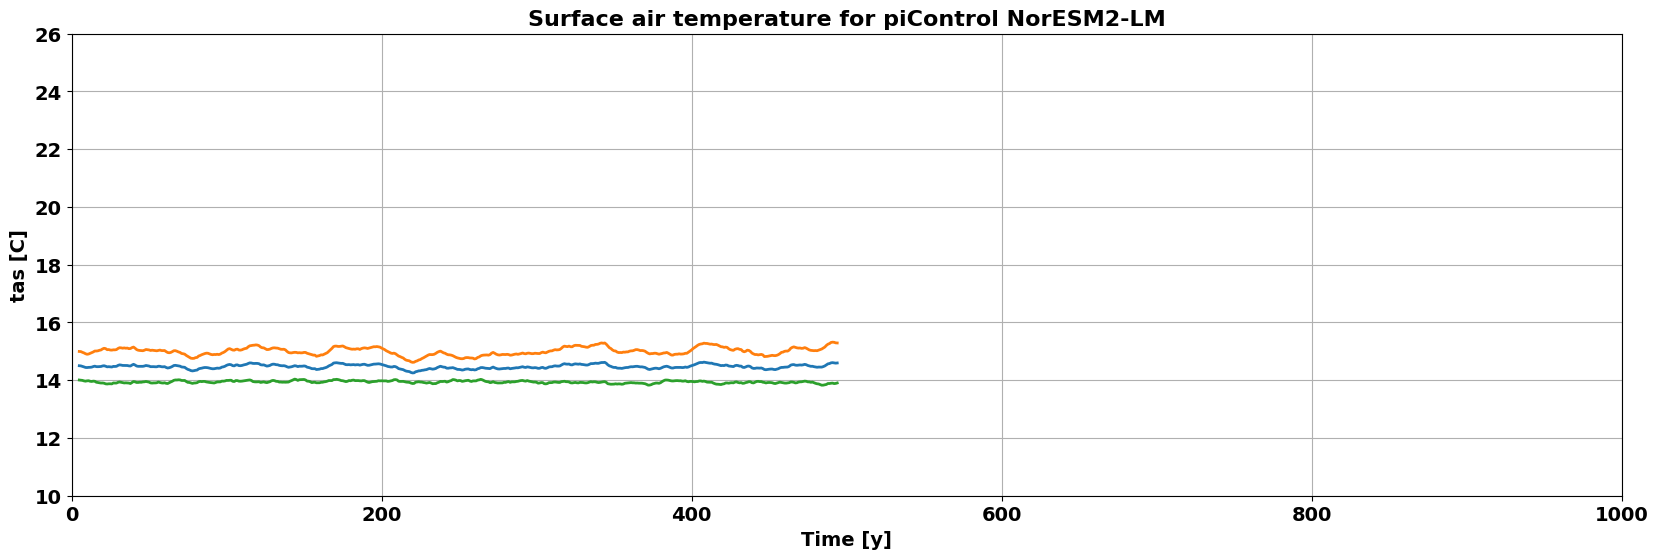

In [10]:
# 1. piControl 
time = np.arange(0, 500)
time_roll=np.arange(5, 495)

plt.figure(figsize=(20, 6))

plt.plot(time_roll, roll_tas_pi_noresm2_gl, color = 'tab:blue', linewidth = 2, label = 'Global')
plt.plot(time_roll, roll_tas_pi_noresm2_nh, color = 'tab:orange', linewidth = 2, label = 'NH')
plt.plot(time_roll, roll_tas_pi_noresm2_sh, color = 'tab:green', linewidth = 2, label = 'SH')

plt.xlim(0, 1000)
plt.ylim(10, 26)
plt.xlabel('Time [y]', fontsize=14, fontweight='bold')
plt.ylabel('tas [C]', fontsize=14, fontweight='bold')
plt.title('Surface air temperature for piControl NorESM2-LM', fontsize=16, fontweight='bold')
plt.grid()
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.show()

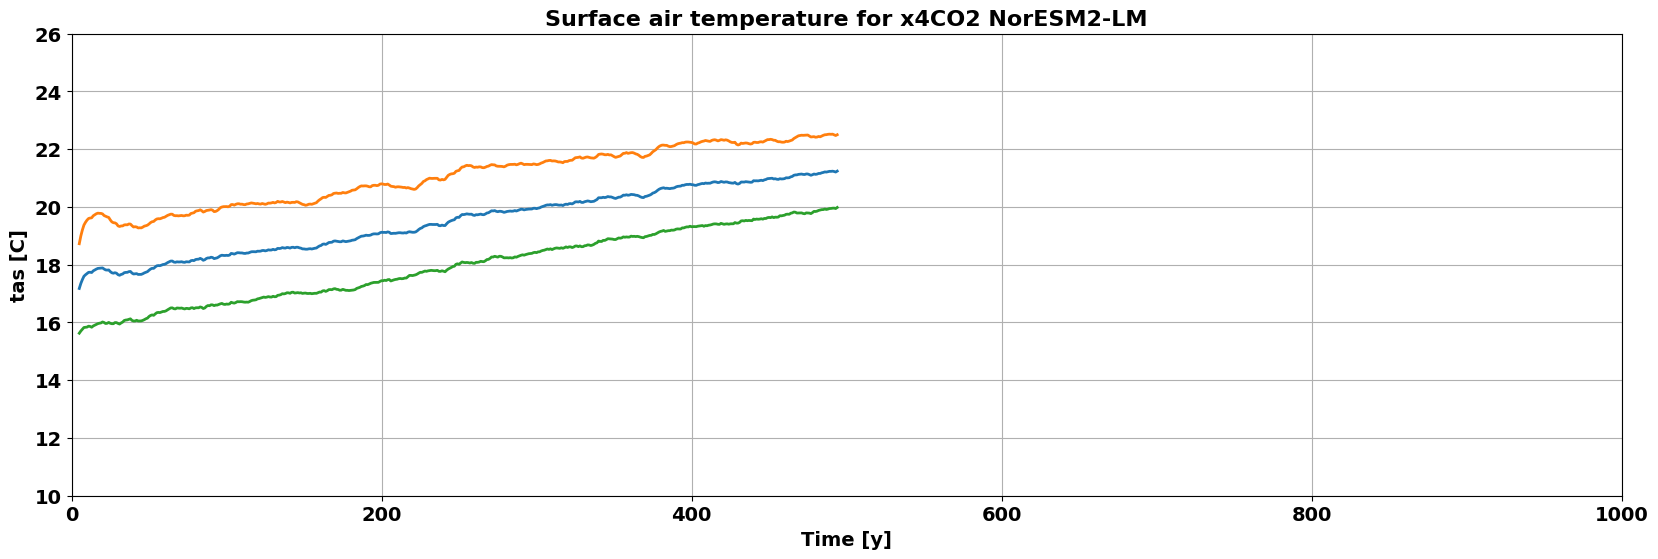

In [11]:
# 2. x4CO2
plt.figure(figsize=(20, 6))

plt.plot(time_roll, roll_tas_x4_noresm2_gl, color = 'tab:blue', linewidth = 2, label = 'Global')
plt.plot(time_roll, roll_tas_x4_noresm2_nh, color = 'tab:orange', linewidth = 2, label = 'NH')
plt.plot(time_roll, roll_tas_x4_noresm2_sh, color = 'tab:green', linewidth = 2, label = 'SH')

plt.xlim(0, 1000)
plt.ylim(10, 26)
plt.xlabel('Time [y]', fontsize=14, fontweight='bold')
plt.ylabel('tas [C]', fontsize=14, fontweight='bold')
plt.title('Surface air temperature for x4CO2 NorESM2-LM', fontsize=16, fontweight='bold')
plt.grid()
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.show()

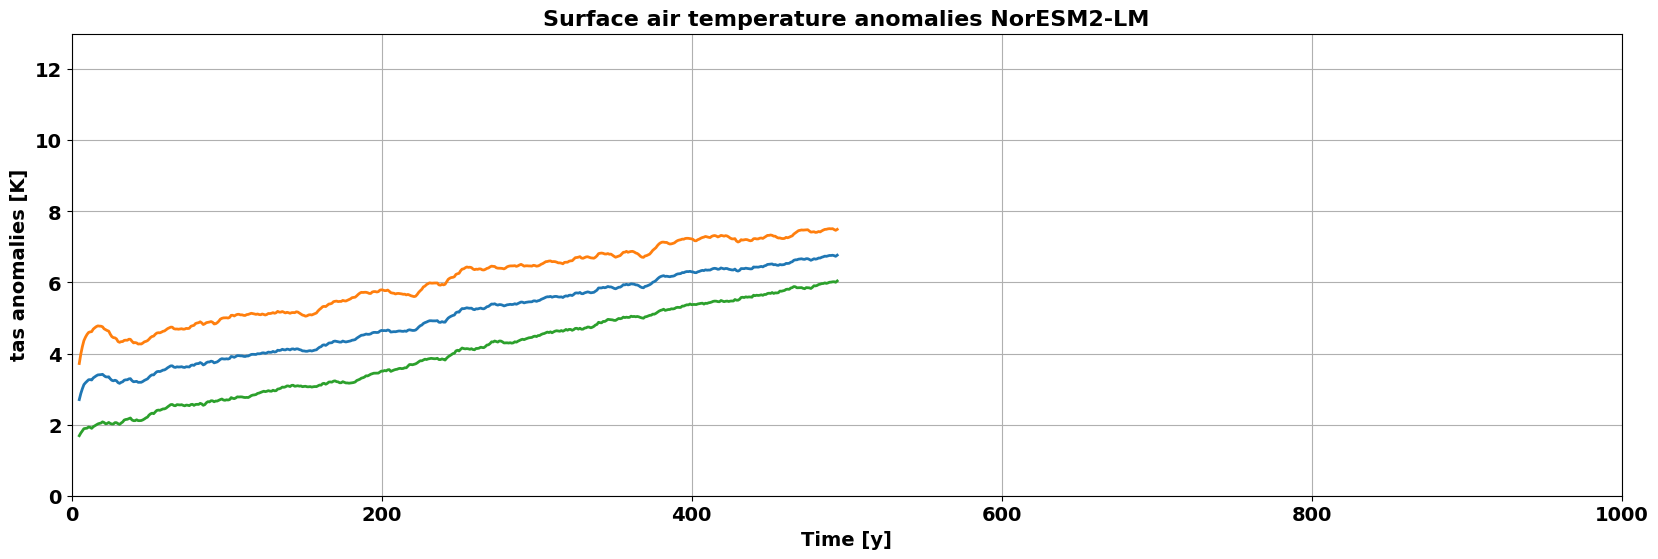

In [12]:
# anomalies
plt.figure(figsize=(20, 6))

plt.plot(time_roll, roll_anom_tas_gl_noresm2, color = 'tab:blue', linewidth = 2, label = 'Global')
plt.plot(time_roll, roll_anom_tas_nh_noresm2, color = 'tab:orange', linewidth = 2, label = 'NH')
plt.plot(time_roll, roll_anom_tas_sh_noresm2, color = 'tab:green', linewidth = 2, label = 'SH')

plt.xlim(0, 1000)
plt.ylim(0, 13)
plt.xlabel('Time [y]', fontsize=14, fontweight='bold')
plt.ylabel('tas anomalies [K]', fontsize=14, fontweight='bold')
plt.title('Surface air temperature anomalies NorESM2-LM', fontsize=16, fontweight='bold')
plt.grid()
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.show()

# **B. IPSL-CM6A-LR**

## **1. Processing the data**

### **1.1 Importing tas from NIRD**

In [13]:
experiments = ['piControl', 'abrupt-4xCO2']

tas_exp_ipsl = []

for experiment in experiments:
            
    folder_path = f'/datalake/NS9560K/ESGF/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/{experiment}/r1i1p1f1/Amon/tas/gr/latest'

    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks={'time': 10}) for file_name in file_names if file_name.endswith('.nc')]
    
    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')
    ds = merged_datasets.isel(time=slice(0, 900*12))

    ds['time'] = to_cftime(ds['time'].values)

    yearly_tas = yearly_avg(ds['tas'])
    
    tas_exp_ipsl.append(yearly_tas)

lon_ipsl = ds['lon'].values     
lat_ipsl = ds['lat'].values

### **1.2. Turning K--> C and selecting the desired timeslices**

In [14]:
tas_exp_ipsl_piControl = tas_exp_ipsl[0]-273.15
tas_exp_ipsl_x4CO2 = tas_exp_ipsl[1]-273.15

tas_ipsl_0_30 = (tas_exp_ipsl_x4CO2.isel(year = slice(0, 30))).mean(dim='year')
tas_ipsl_120_150 = (tas_exp_ipsl_x4CO2.isel(year = slice(120, 150))).mean(dim='year')
tas_ipsl_470_500 = (tas_exp_ipsl_x4CO2.isel(year = slice(470,500))).mean(dim='year')
tas_ipsl_870_900 = (tas_exp_ipsl_x4CO2.isel(year = slice(870,900))).mean(dim='year')

tas_ipsl_piControl = (tas_exp_ipsl_piControl.isel(year = slice(0, 30))).mean(dim='year')

## **2. Zonal plots of Air temperature and anomalies vs latitude**

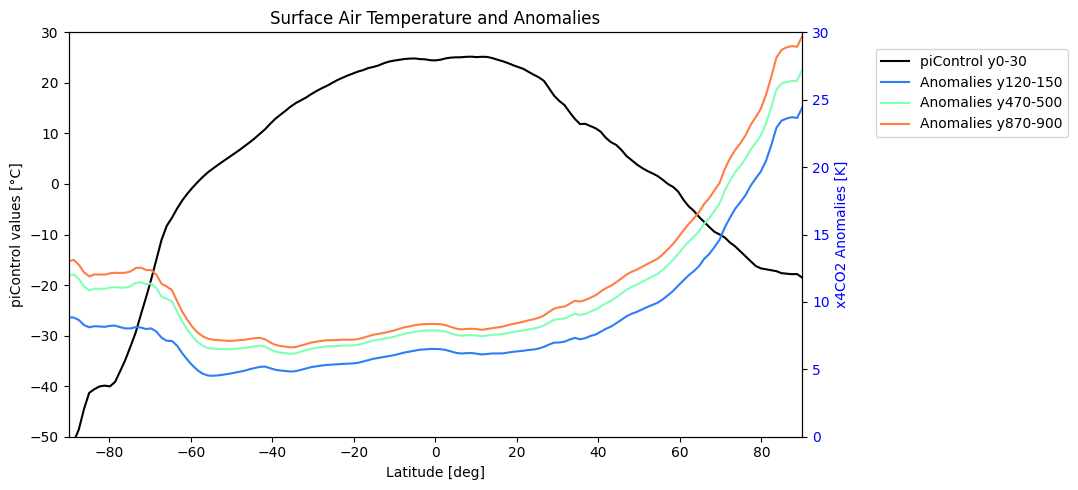

In [15]:
# piControl & anomalies

fig, ax = plt.subplots(figsize=(11,5))

# --- Main axis (absolute temperature) ---
ax.plot(lat_ipsl, tas_ipsl_piControl.mean(dim='lon'),
        color='black', label='piControl y0-30')
ax.set_xlabel('Latitude [deg]')
ax.set_ylabel('piControl values [°C]', color='black')
ax.tick_params(axis='y', labelcolor='black')

# --- Twin axis for anomalies ---
ax2 = ax.twinx()

ax2.plot(lat_ipsl, tas_ipsl_120_150.mean(dim='lon') - tas_ipsl_piControl.mean(dim='lon'),
         color=colors[1], label='Anomalies y120-150')
ax2.plot(lat_ipsl, tas_ipsl_470_500.mean(dim='lon') - tas_ipsl_piControl.mean(dim='lon'),
         color=colors[3], label='Anomalies y470-500')
ax2.plot(lat_ipsl, tas_ipsl_870_900.mean(dim='lon') - tas_ipsl_piControl.mean(dim='lon'),
         color=colors[5], label='Anomalies y870-900')

ax2.set_ylabel('x4CO2 Anomalies [K]', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# --- Combine legends from both axes ---
# --- Combine legends from both axes ---
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# Legend outside the plot
ax.legend(lines + lines2, labels + labels2,
          loc='center left', bbox_to_anchor=(1.1, 0.85), borderaxespad=0.)
ax.set_ylim(-50, 30)
ax2.set_ylim(0, 30)
ax.set_xlim(-90, 90)

plt.title('Surface Air Temperature and Anomalies')
plt.tight_layout()
plt.show()


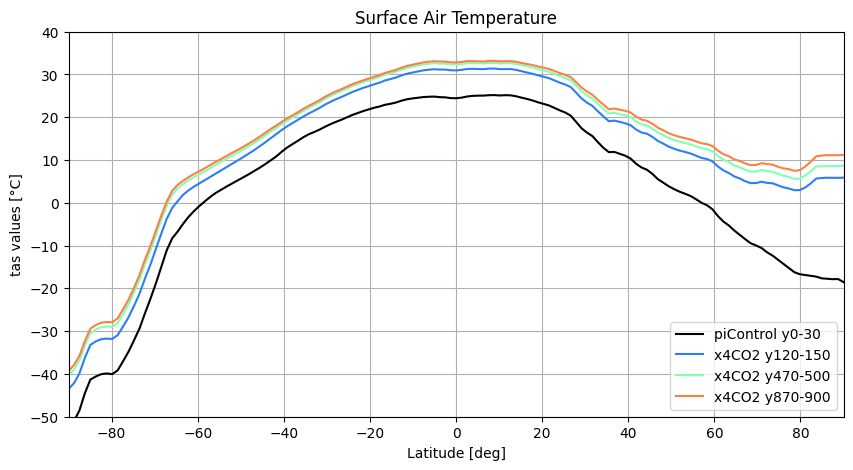

In [16]:
#2. piControl & x4CO2

fig, ax = plt.subplots(figsize=(10,5))

# --- Main axis (absolute temperature) ---
plt.plot(lat_ipsl, tas_ipsl_piControl.mean(dim='lon'),
        color='black', label='piControl y0-30')

plt.plot(lat_ipsl, tas_ipsl_120_150.mean(dim='lon'),
         color=colors[1], label='x4CO2 y120-150')
plt.plot(lat_ipsl, tas_ipsl_470_500.mean(dim='lon'),
         color=colors[3], label='x4CO2 y470-500')
plt.plot(lat_ipsl, tas_ipsl_870_900.mean(dim='lon'),
         color=colors[5], label='x4CO2 y870-900')

plt.xlabel('Latitude [deg]')
plt.ylabel('tas values [°C]', color='black')
plt.xlim(-90, 90)
plt.ylim(-50, 40)
plt.legend(loc='lower right')
plt.title('Surface Air Temperature')
plt.grid()
plt.show()

## **3. tas timeseries for piControl, x4CO2 and Anomalies (rolling average)**

### **3.1. Getting tas hemispherically and globally averaged**

In [17]:
tas_pi_ipsl_gl = areaavg(tas_exp_ipsl[0].to_dataset(name = "restom"), "restom")-273.15
tas_pi_ipsl_nh = areaavg((tas_exp_ipsl[0].sel(lat=slice(0,None))).to_dataset(name = "restom"), "restom")-273.15
tas_pi_ipsl_sh = areaavg((tas_exp_ipsl[0].sel(lat=slice(None,0))).to_dataset(name = "restom"), "restom")-273.15

tas_x4CO2_ipsl_gl = areaavg(tas_exp_ipsl[1].to_dataset(name = "restom"), "restom")-273.15
tas_x4CO2_ipsl_nh = areaavg((tas_exp_ipsl[1].sel(lat=slice(0,None))).to_dataset(name = "restom"), "restom")-273.15
tas_x4CO2_ipsl_sh = areaavg((tas_exp_ipsl[1].sel(lat=slice(None,0))).to_dataset(name = "restom"), "restom")-273.15

In [18]:
#anom_tas_ipsl_gl = np.array([tas_x4CO2_ipsl_gl[i]-np.mean(tas_pi_ipsl_gl) for i in range(0, 900)])
#anom_tas_ipsl_nh = np.array([tas_x4CO2_ipsl_nh[i]-np.mean(tas_pi_ipsl_nh) for i in range(0, 900)])
#anom_tas_ipsl_sh = np.array([tas_x4CO2_ipsl_sh[i]-np.mean(tas_pi_ipsl_sh) for i in range(0, 900)])

# Faster way to get the difference:

anom_tas_ipsl_gl = tas_x4CO2_ipsl_gl[:900] - np.mean(tas_pi_ipsl_gl)

anom_tas_ipsl_nh = tas_x4CO2_ipsl_nh[:900] - np.mean(tas_pi_ipsl_nh)

anom_tas_ipsl_sh = tas_x4CO2_ipsl_sh[:900] - np.mean(tas_pi_ipsl_sh)

### **3.2. Applying a rolling average**

In [19]:
# rolling_average_ts takes too much time now. So we go for the convolve function.

roll_tas_pi_ipsl_gl = convolve_f(tas_pi_ipsl_gl, 11)
roll_tas_pi_ipsl_nh = convolve_f(tas_pi_ipsl_nh, 11)
roll_tas_pi_ipsl_sh = convolve_f(tas_pi_ipsl_sh, 11)

roll_tas_x4_ipsl_gl = convolve_f(tas_x4CO2_ipsl_gl, 11)
roll_tas_x4_ipsl_nh = convolve_f(tas_x4CO2_ipsl_nh, 11)
roll_tas_x4_ipsl_sh = convolve_f(tas_x4CO2_ipsl_sh, 11)

roll_anom_tas_gl_ipsl = convolve_f(anom_tas_ipsl_gl, 11)
roll_anom_tas_nh_ipsl = convolve_f(anom_tas_ipsl_nh, 11)
roll_anom_tas_sh_ipsl = convolve_f(anom_tas_ipsl_sh, 11)

### **3.3. Plotting**

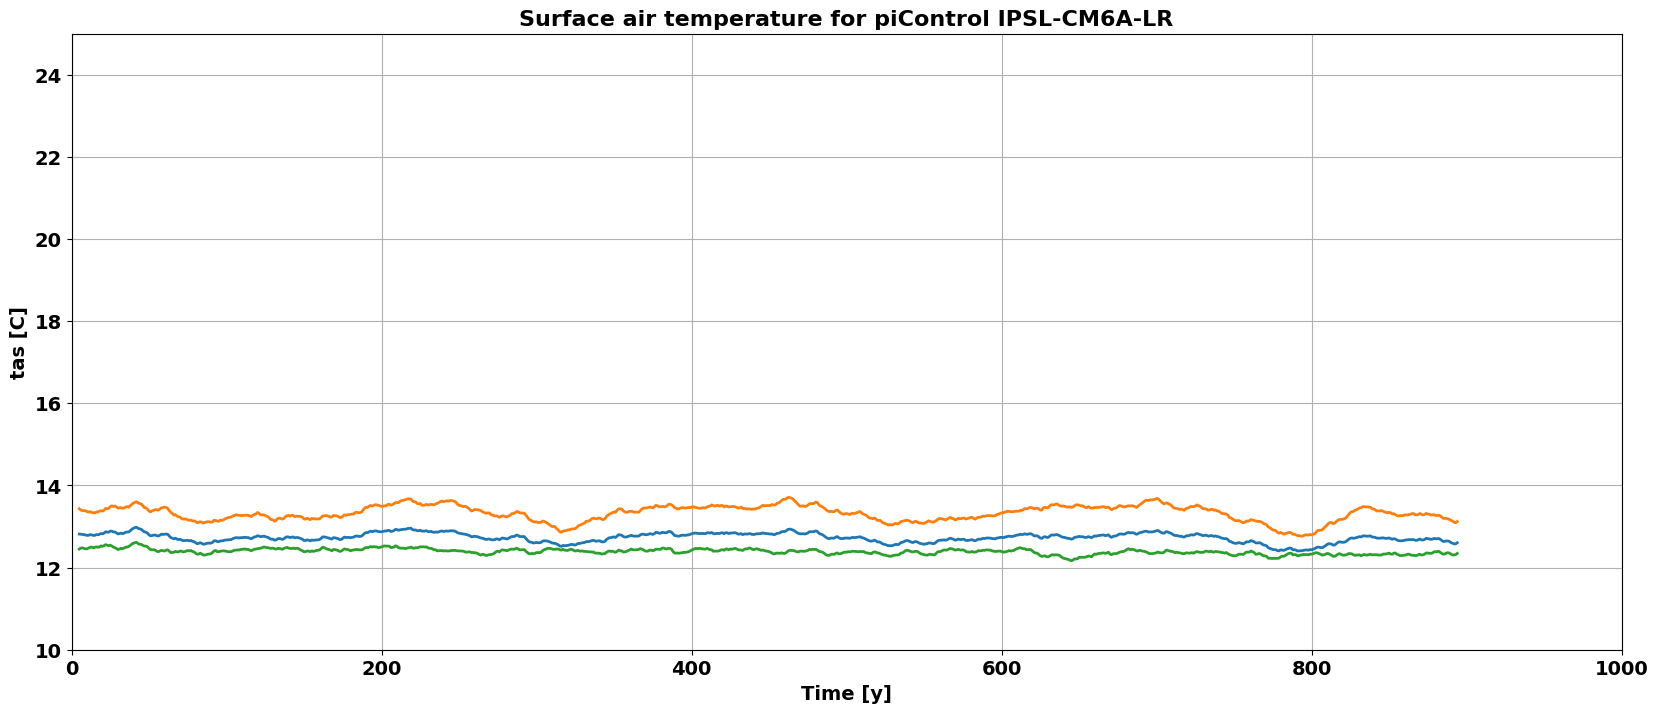

In [20]:
# 1. piControl

time = np.arange(5, 895)
plt.figure(figsize=(20, 8))

plt.plot(time, roll_tas_pi_ipsl_gl, linewidth = 2, label = 'Global')
plt.plot(time, roll_tas_pi_ipsl_nh, linewidth = 2,  label = 'NH')
plt.plot(time, roll_tas_pi_ipsl_sh, linewidth = 2, label = 'SH')
plt.xlim(0, 1000)
plt.ylim(10, 25)
plt.xlabel('Time [y]', fontsize=14, fontweight='bold')
plt.ylabel('tas [C]', fontsize=14, fontweight='bold')
plt.title('Surface air temperature for piControl IPSL-CM6A-LR', fontsize=16, fontweight='bold')
plt.grid()
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.show()

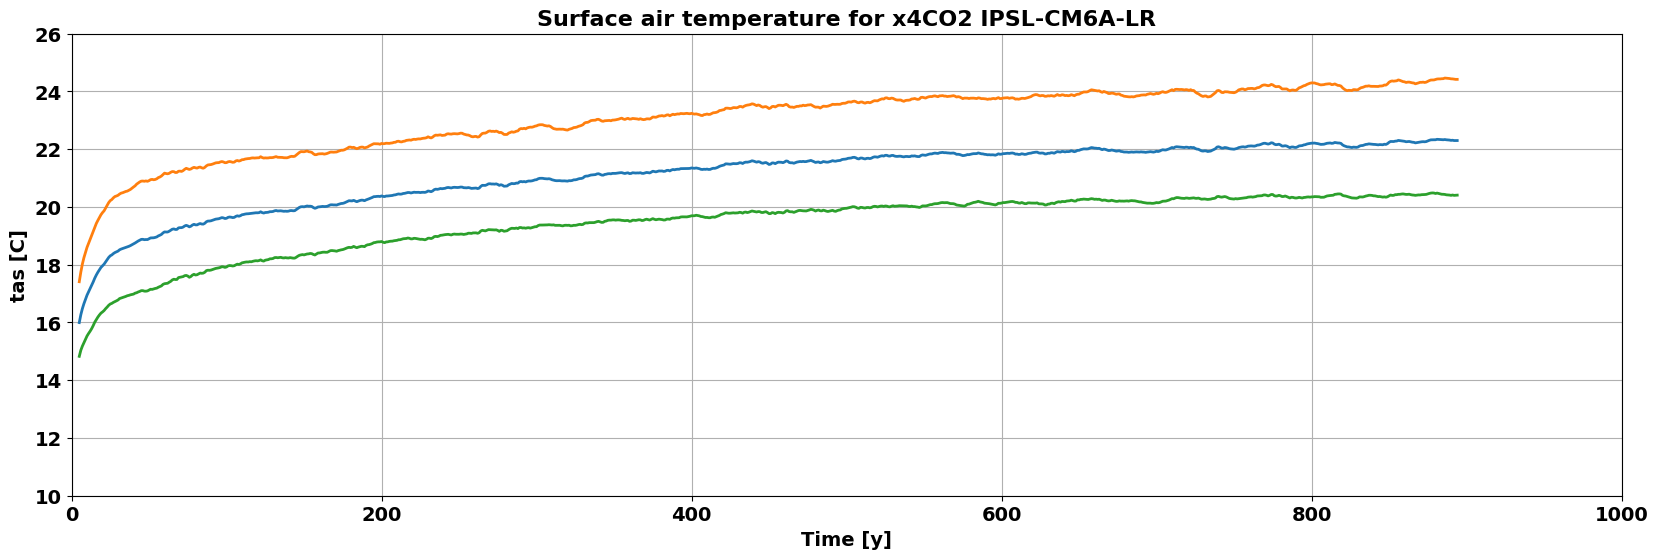

In [21]:
# 2. x4CO2

plt.figure(figsize=(20, 6))

plt.plot(time, roll_tas_x4_ipsl_gl, color = 'tab:blue', linewidth = 2, label = 'Global')
plt.plot(time, roll_tas_x4_ipsl_nh, color = 'tab:orange', linewidth = 2, label = 'NH')
plt.plot(time, roll_tas_x4_ipsl_sh, color = 'tab:green', linewidth = 2, label = 'SH')

plt.xlim(0, 1000)
plt.ylim(10, 26)
plt.xlabel('Time [y]', fontsize=14, fontweight='bold')
plt.ylabel('tas [C]', fontsize=14, fontweight='bold')
plt.title('Surface air temperature for x4CO2 IPSL-CM6A-LR', fontsize=16, fontweight='bold')
plt.grid()
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.show()

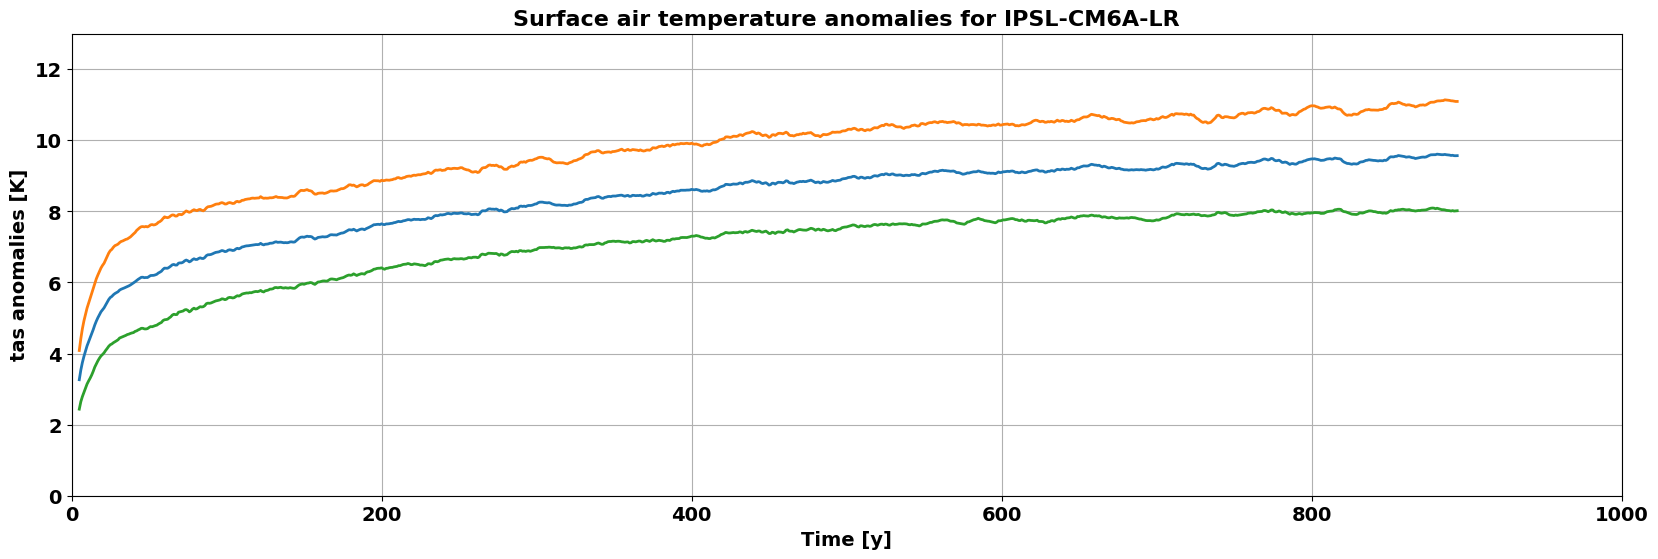

In [22]:
# 3. anomalies

plt.figure(figsize=(20, 6))

plt.plot(time, roll_anom_tas_gl_ipsl, color = 'tab:blue', linewidth = 2, label = 'Global')
plt.plot(time, roll_anom_tas_nh_ipsl, color = 'tab:orange', linewidth = 2, label = 'NH')
plt.plot(time, roll_anom_tas_sh_ipsl, color = 'tab:green', linewidth = 2, label = 'SH')

plt.xlim(0, 1000)
plt.ylim(0, 13)
plt.xlabel('Time [y]', fontsize=14, fontweight='bold')
plt.ylabel('tas anomalies [K]', fontsize=14, fontweight='bold')
plt.title('Surface air temperature anomalies for IPSL-CM6A-LR', fontsize=16, fontweight='bold')
plt.grid()
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.show()

# **C. CESM2**

## **1. Processing the data**

### **1.1 Importing tas from NIRD**

In [23]:
experiments = ['piControl', 'abrupt-4xCO2']

tas_exp_cesm2 = []

for experiment in experiments:
            
    folder_path = f'/datalake/NS9560K/ESGF/CMIP6/CMIP/NCAR/CESM2/{experiment}/r1i1p1f1/Amon/tas/gn/latest'

    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks={'time': 10}) for file_name in file_names if file_name.endswith('.nc')]
    
    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')
    ds = merged_datasets.isel(time=slice(0, 999*12))

    yearly_tas = yearly_avg(ds['tas'])
    
    tas_exp_cesm2.append(yearly_tas)

lon = ds['lon'].values     
lat = ds['lat'].values

### **1.2. Turning K--> C and selecting the desired timeslices**

In [24]:
tas_exp_cesm2_piControl = tas_exp_cesm2[0]-273.15
tas_exp_cesm2_x4CO2 = tas_exp_cesm2[1]-273.15

In [25]:
tas_cesm2_0_30 = (tas_exp_cesm2_x4CO2.isel(year = slice(0, 30))).mean(dim='year')
tas_cesm2_120_150 = (tas_exp_cesm2_x4CO2.isel(year = slice(120, 150))).mean(dim='year')
tas_cesm2_470_500 = (tas_exp_cesm2_x4CO2.isel(year = slice(470,500))).mean(dim='year')
tas_cesm2_870_900 = (tas_exp_cesm2_x4CO2.isel(year = slice(870,900))).mean(dim='year')
tas_cesm2_970_999 = (tas_exp_cesm2_x4CO2.isel(year = slice(970,999))).mean(dim='year')

tas_cesm2_piControl = (tas_exp_cesm2_piControl.isel(year = slice(0, 30))).mean(dim='year')

## **2. Zonal mean temperature vs latitude**

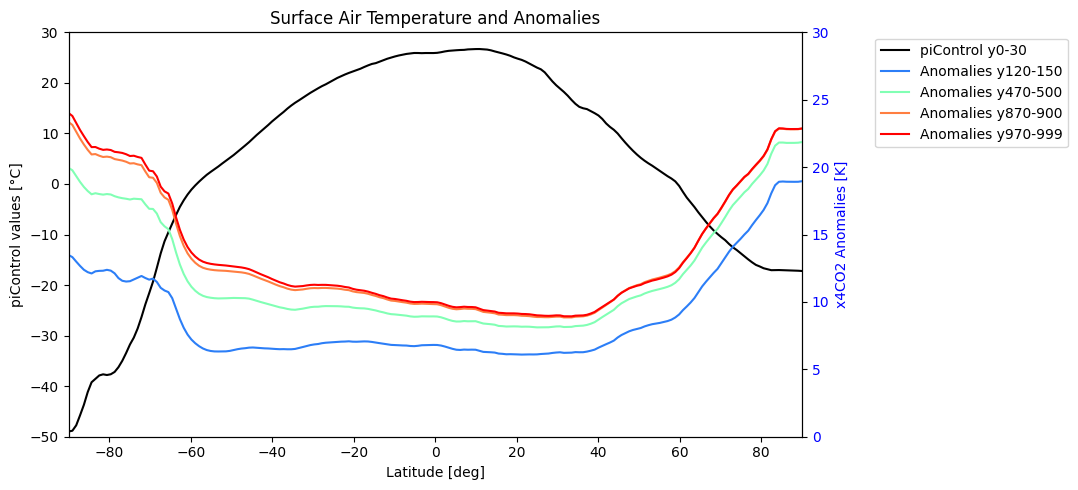

In [26]:
# 1. piControl & anomalies

fig, ax = plt.subplots(figsize=(11,5))

# --- Main axis (absolute temperature) ---
ax.plot(lat, tas_cesm2_piControl.mean(dim='lon'),
        color='black', label='piControl y0-30')
ax.set_xlabel('Latitude [deg]')
ax.set_ylabel('piControl values [°C]', color='black')
ax.tick_params(axis='y', labelcolor='black')

# --- Twin axis for anomalies ---
ax2 = ax.twinx()

ax2.plot(lat, tas_cesm2_120_150.mean(dim='lon') - tas_cesm2_piControl.mean(dim='lon'),
         color=colors[1], label='Anomalies y120-150')
ax2.plot(lat, tas_cesm2_470_500.mean(dim='lon') - tas_cesm2_piControl.mean(dim='lon'),
         color=colors[3], label='Anomalies y470-500')
ax2.plot(lat, tas_cesm2_870_900.mean(dim='lon') - tas_cesm2_piControl.mean(dim='lon'),
         color=colors[5], label='Anomalies y870-900')
ax2.plot(lat, tas_cesm2_970_999.mean(dim='lon') - tas_cesm2_piControl.mean(dim='lon'),
         color=colors[6], label='Anomalies y970-999')

ax2.set_ylabel('x4CO2 Anomalies [K]', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# --- Combine legends from both axes ---
# --- Combine legends from both axes ---
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# Legend outside the plot
ax.legend(lines + lines2, labels + labels2,
          loc='center left', bbox_to_anchor=(1.1, 0.85), borderaxespad=0.)
ax.set_ylim(-50, 30)
ax2.set_ylim(0, 30)
ax.set_xlim(-90, 90)
plt.title('Surface Air Temperature and Anomalies')
plt.tight_layout()
plt.show()


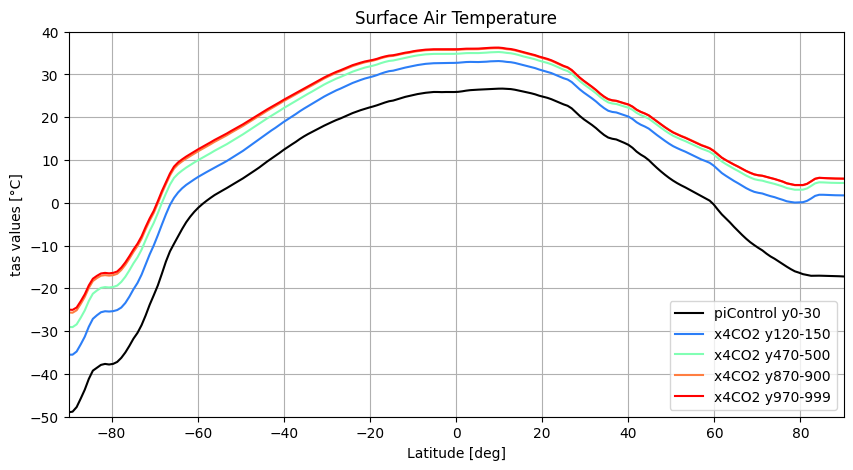

In [27]:
# 2. piControl & x4CO2
fig, ax = plt.subplots(figsize=(10,5))

# --- Main axis (absolute temperature) ---
plt.plot(lat, tas_cesm2_piControl.mean(dim='lon'),
        color='black', label='piControl y0-30')

plt.plot(lat, tas_cesm2_120_150.mean(dim='lon'),
         color=colors[1], label='x4CO2 y120-150')
plt.plot(lat, tas_cesm2_470_500.mean(dim='lon'),
         color=colors[3], label='x4CO2 y470-500')
plt.plot(lat, tas_cesm2_870_900.mean(dim='lon'),
         color=colors[5], label='x4CO2 y870-900')
plt.plot(lat, tas_cesm2_970_999.mean(dim='lon'),
         color=colors[6], label='x4CO2 y970-999')

plt.xlabel('Latitude [deg]')
plt.ylabel('tas values [°C]', color='black')
plt.xlim(-90, 90)
plt.ylim(-50, 40)

plt.legend()
plt.title('Surface Air Temperature')
plt.grid()
plt.show()

## **3. tas timeseries for piControl, x4CO2 and Anomalies (rolling average)**

### **3.1. Getting tas hemispherically and globally averaged**

In [28]:
tas_piControl_gl_cesm2 = areaavg(tas_exp_cesm2[0].to_dataset(name = "restom"), "restom")-273.15
tas_piControl_nh_cesm2 = areaavg((tas_exp_cesm2[0].sel(lat=slice(0,None))).to_dataset(name = "restom"), "restom")-273.15
tas_piControl_sh_cesm2 = areaavg((tas_exp_cesm2[0].sel(lat=slice(None,0))).to_dataset(name = "restom"), "restom")-273.15

tas_x4CO2_gl_cesm2 = (areaavg(tas_exp_cesm2[1].to_dataset(name = "restom"), "restom")-273.15)#.values
tas_x4CO2_nh_cesm2 = (areaavg((tas_exp_cesm2[1].sel(lat=slice(0,None))).to_dataset(name = "restom"), "restom")-273.15)#.values
tas_x4CO2_sh_cesm2 = (areaavg((tas_exp_cesm2[1].sel(lat=slice(None,0))).to_dataset(name = "restom"), "restom")-273.15)#.values

anom_tas_gl_cesm2 = tas_x4CO2_gl_cesm2[:999] - np.mean(tas_piControl_gl_cesm2)

anom_tas_nh_cesm2 = tas_x4CO2_nh_cesm2[:999] - np.mean(tas_piControl_nh_cesm2)

anom_tas_sh_cesm2 = tas_x4CO2_sh_cesm2[:999] - np.mean(tas_piControl_sh_cesm2)

### **3.2. Applying a rolling average**

In [29]:
roll_tas_pi_cesm2_gl = convolve_f(tas_piControl_gl_cesm2, 11)
roll_tas_pi_cesm2_nh = convolve_f(tas_piControl_nh_cesm2, 11)
roll_tas_pi_cesm2_sh = convolve_f(tas_piControl_sh_cesm2, 11)

roll_tas_x4_cesm2_gl = convolve_f(tas_x4CO2_gl_cesm2, 11)
roll_tas_x4_cesm2_nh = convolve_f(tas_x4CO2_nh_cesm2, 11)
roll_tas_x4_cesm2_sh = convolve_f(tas_x4CO2_sh_cesm2, 11)

roll_anom_tas_gl_cesm2 = convolve_f(anom_tas_gl_cesm2, 11)
roll_anom_tas_nh_cesm2 = convolve_f(anom_tas_nh_cesm2, 11)
roll_anom_tas_sh_cesm2 = convolve_f(anom_tas_sh_cesm2, 11)

## **3.3. Plotting**

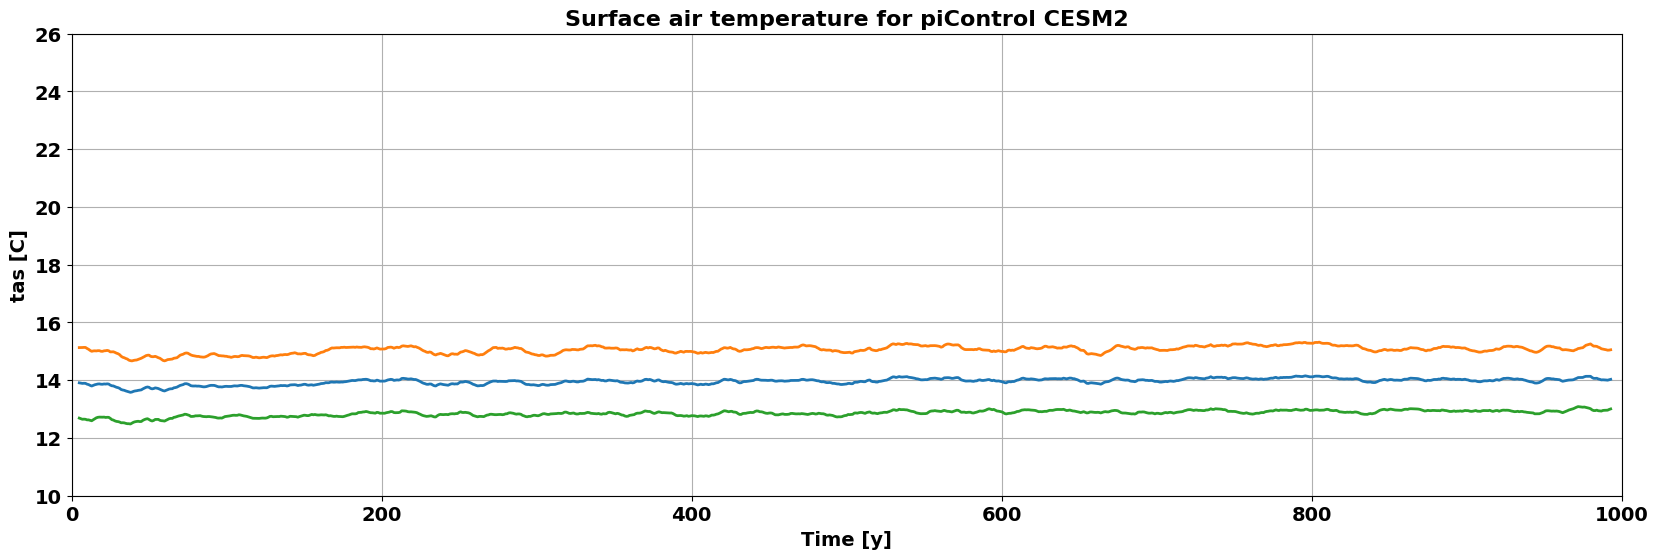

In [30]:
# 1. piControl 

time = np.arange(5, 994)
plt.figure(figsize=(20, 6))

plt.plot(time, roll_tas_pi_cesm2_gl, linewidth = 2, label = 'Global')
plt.plot(time, roll_tas_pi_cesm2_nh, linewidth = 2, label = 'NH')
plt.plot(time, roll_tas_pi_cesm2_sh, linewidth = 2, label = 'SH')

plt.xlim(0, 1000)
plt.ylim(10, 26)

plt.xlabel('Time [y]', fontsize=14, fontweight='bold')
plt.ylabel('tas [C]', fontsize=14, fontweight='bold')
plt.title('Surface air temperature for piControl CESM2', fontsize=16, fontweight='bold')
plt.grid()
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.show()

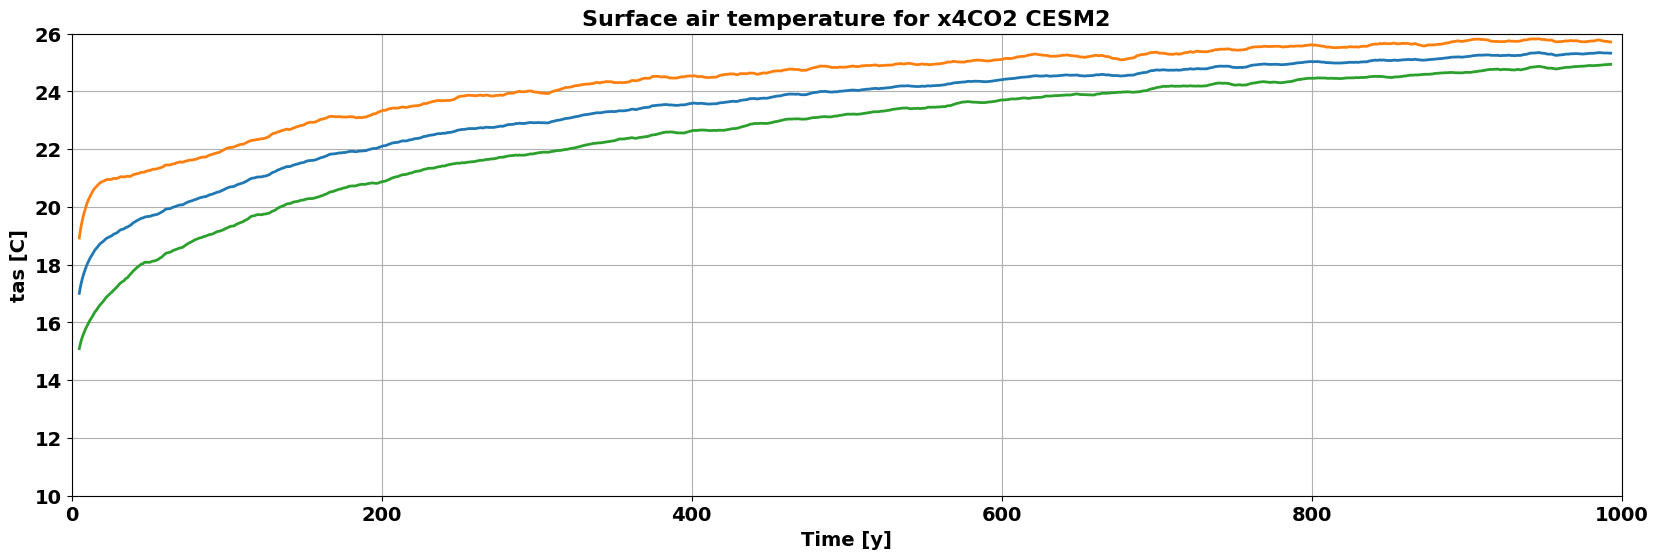

In [31]:
# 2. x4CO2

time = np.arange(5, 994)
plt.figure(figsize=(20, 6))

plt.plot(time, roll_tas_x4_cesm2_gl, linewidth = 2, label = 'Global')
plt.plot(time, roll_tas_x4_cesm2_nh, linewidth = 2, label = 'NH')
plt.plot(time, roll_tas_x4_cesm2_sh, linewidth = 2, label = 'SH')

plt.xlim(0, 1000)
plt.ylim(10, 26)

plt.xlabel('Time [y]', fontsize=14, fontweight='bold')
plt.ylabel('tas [C]', fontsize=14, fontweight='bold')
plt.title('Surface air temperature for x4CO2 CESM2', fontsize=16, fontweight='bold')
plt.grid()
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.show()

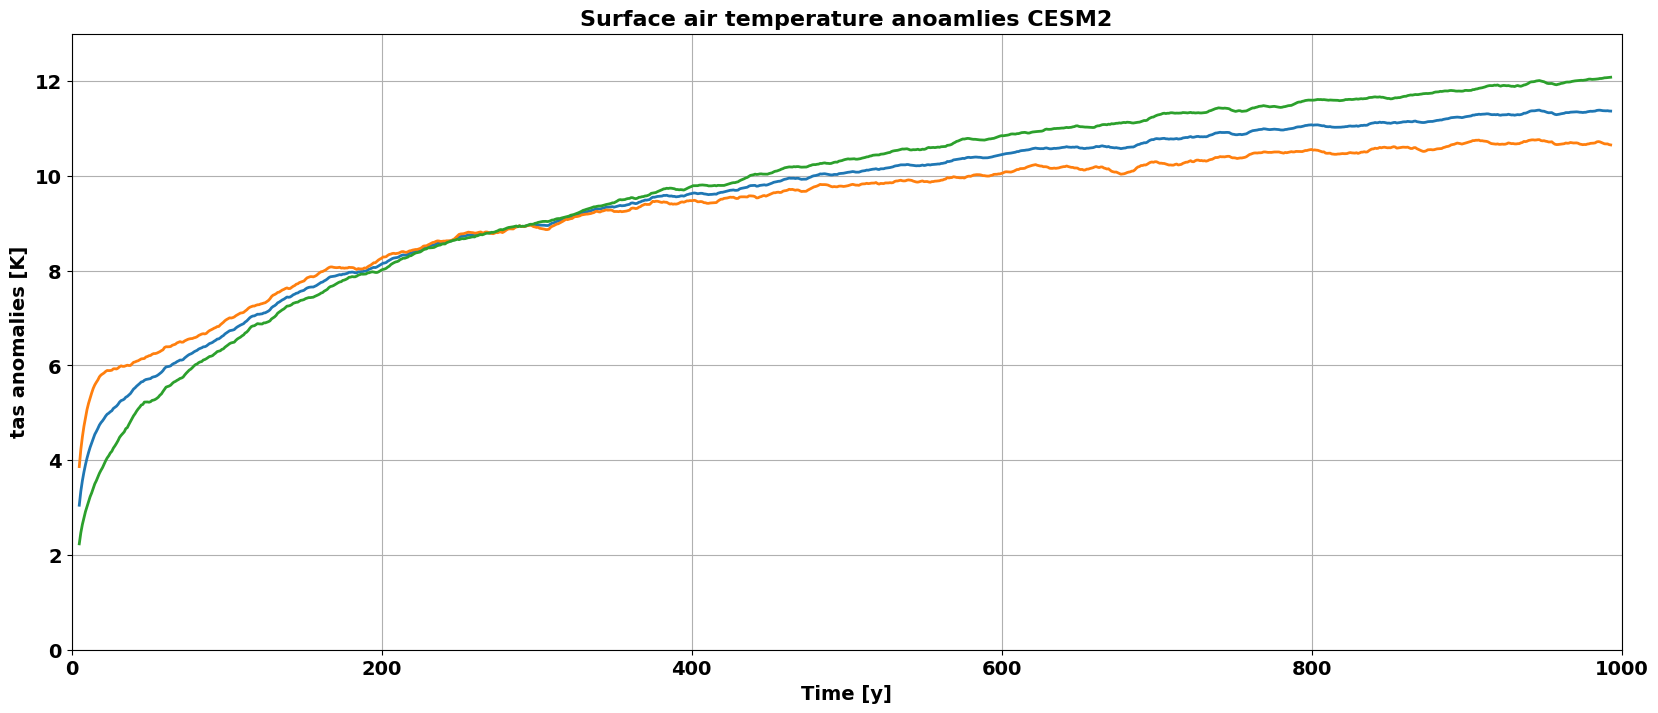

In [32]:
# 3. anomalies

time = np.arange(5, 994)

plt.figure(figsize=(20, 8))

plt.plot(time, roll_anom_tas_gl_cesm2, linewidth = 2, color = 'tab:blue')

plt.plot(time, roll_anom_tas_nh_cesm2, linewidth = 2, color = 'tab:orange')

plt.plot(time, roll_anom_tas_sh_cesm2, linewidth = 2, color = 'tab:green')

plt.xlim(0, 1000)
plt.ylim(0, 13)

plt.xlabel('Time [y]', fontsize=14, fontweight='bold')
plt.ylabel('tas anomalies [K]', fontsize=14, fontweight='bold')
plt.title('Surface air temperature anoamlies CESM2', fontsize=16, fontweight='bold')
plt.grid()
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.show()

# **D. Alternative Plotting**

## **1. Plotting everything in one panel**

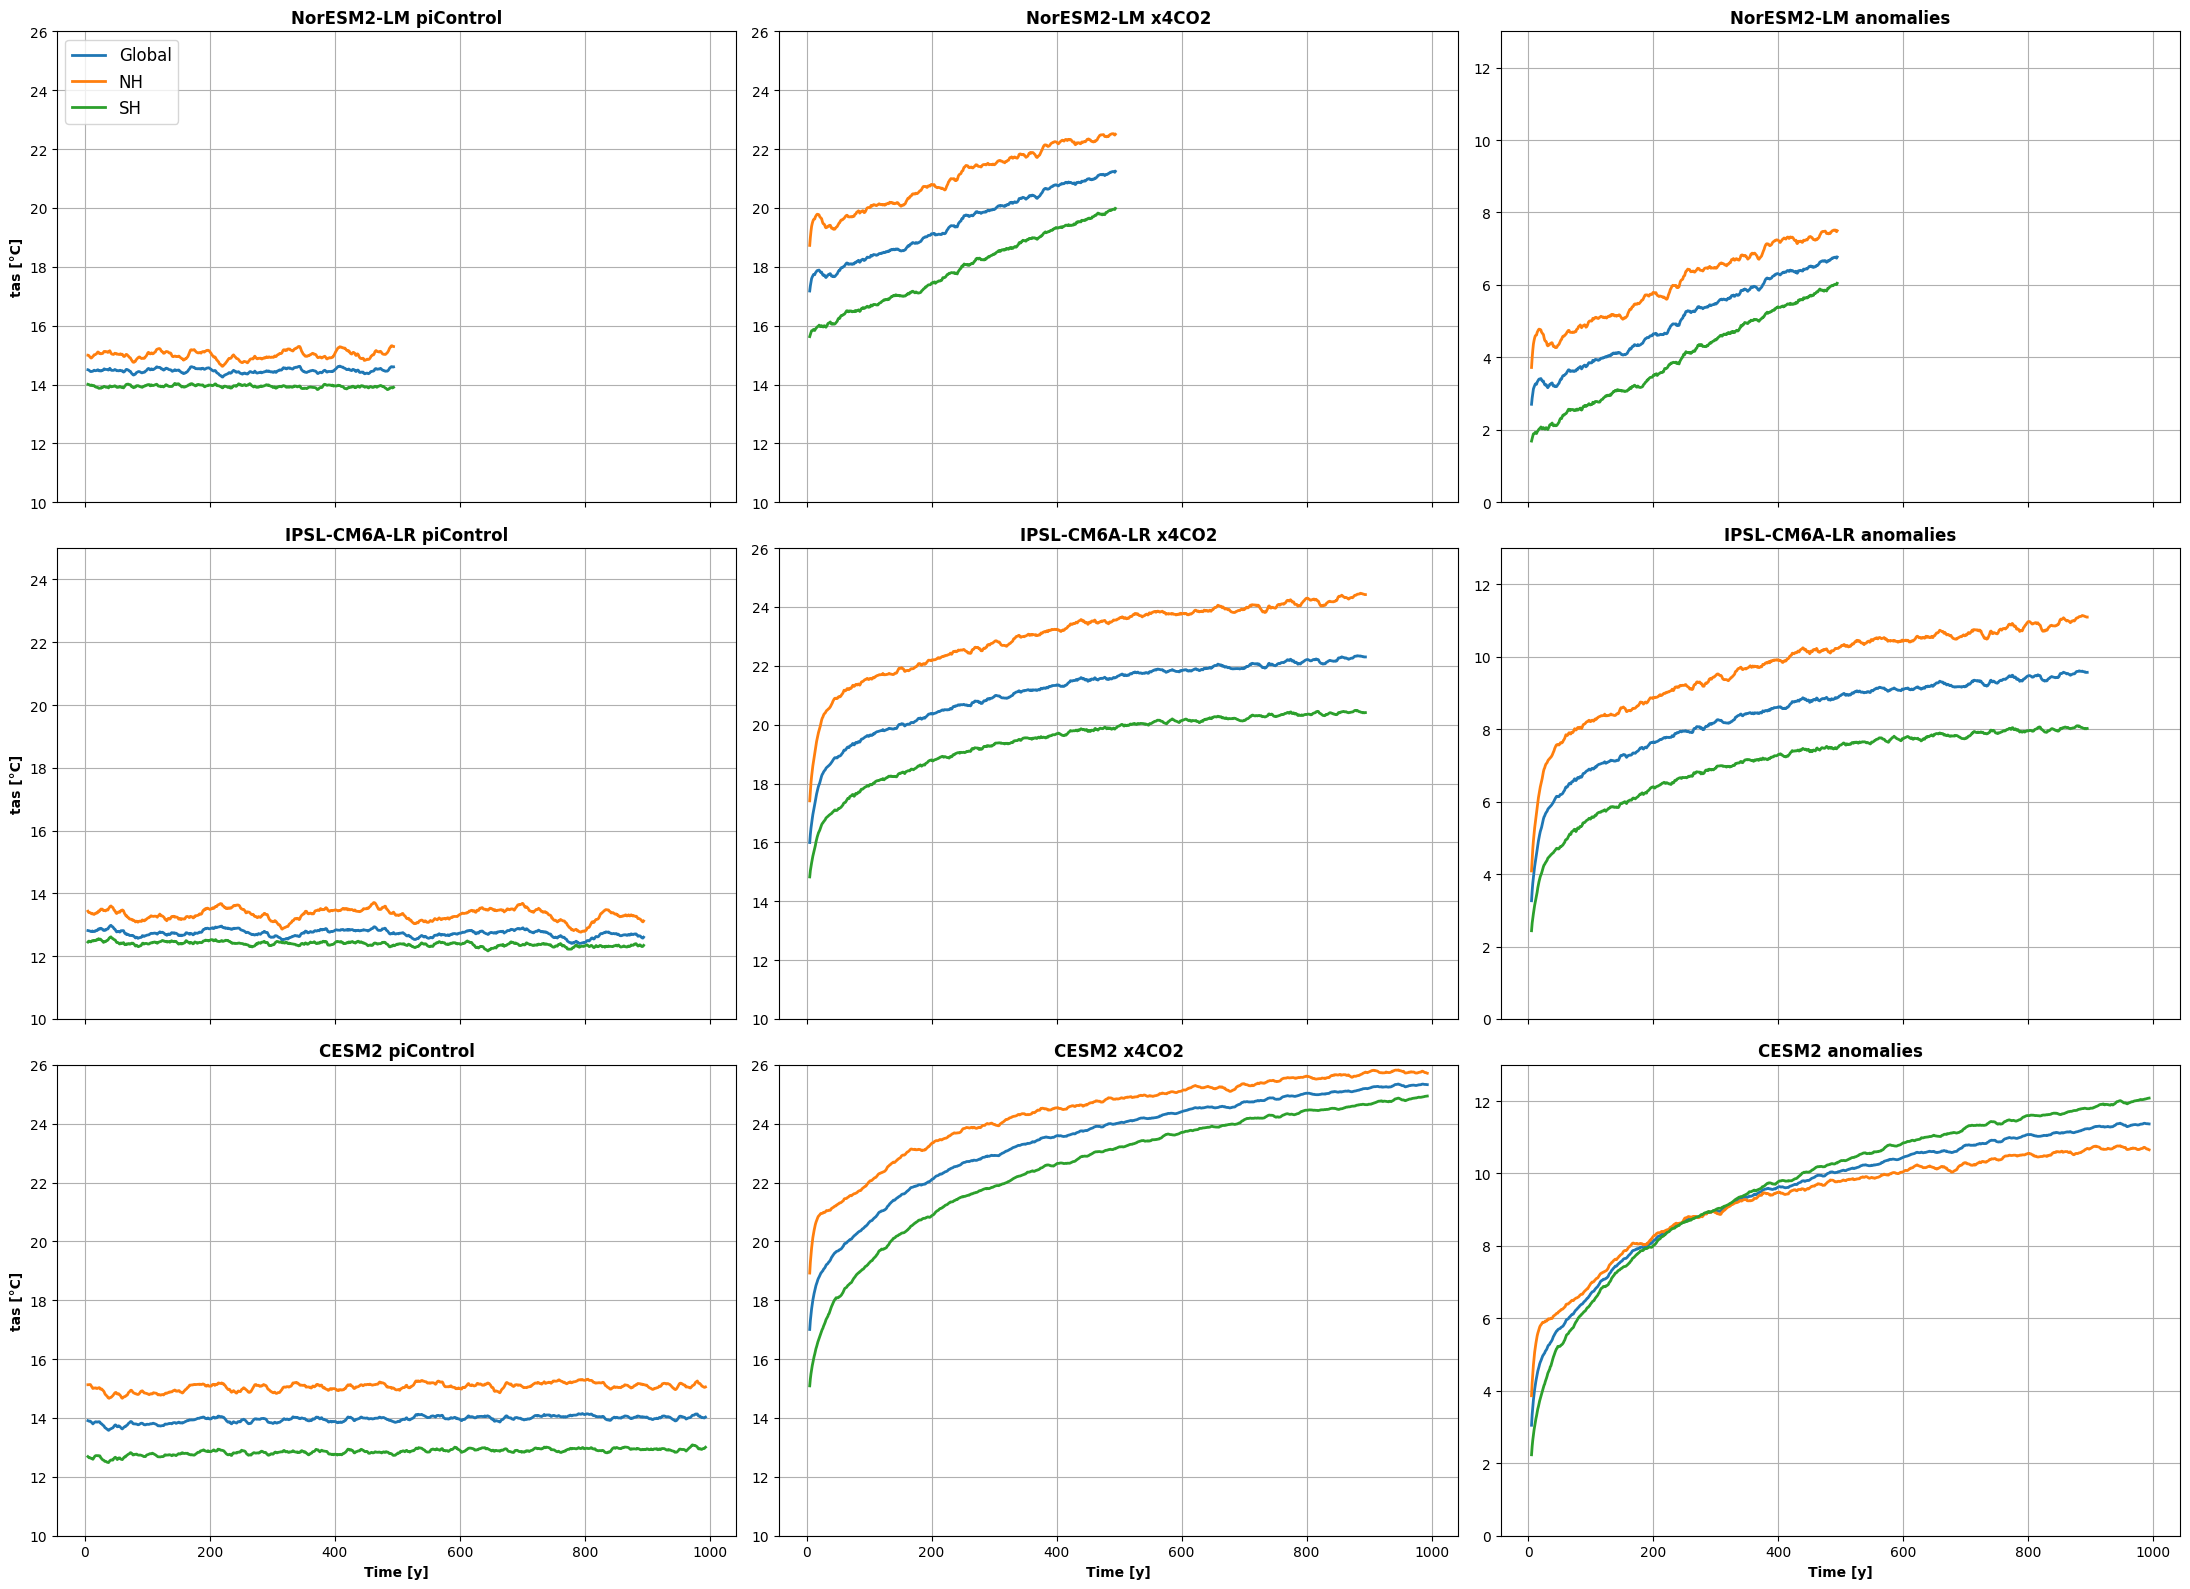

In [33]:
fig, axes = plt.subplots(
    nrows=3, ncols=3,
    figsize=(22, 16),
    sharex=True
)

# =========================
# Time axes
# =========================
time_cesm = np.arange(5, 994)
time_noresm = np.arange(5, 495)
time_ipsl = np.arange(5, 895)

# =========================
# ---- ROW 1: NorESM2-LM
# =========================
# piControl
ax = axes[0, 0]
ax.plot(time_noresm, roll_tas_pi_noresm2_gl, lw=2, label="Global")
ax.plot(time_noresm, roll_tas_pi_noresm2_nh, lw=2, label="NH")
ax.plot(time_noresm, roll_tas_pi_noresm2_sh, lw=2, label="SH")
ax.set_title("NorESM2-LM piControl", fontweight="bold")
ax.set_ylim(10, 26)
ax.grid()

# x4CO2
ax = axes[0, 1]
ax.plot(time_noresm, roll_tas_x4_noresm2_gl, lw=2)
ax.plot(time_noresm, roll_tas_x4_noresm2_nh, lw=2)
ax.plot(time_noresm, roll_tas_x4_noresm2_sh, lw=2)
ax.set_title("NorESM2-LM x4CO2", fontweight="bold")
ax.set_ylim(10, 26)
ax.grid()

# anomalies
ax = axes[0, 2]
ax.plot(time_noresm, roll_anom_tas_gl_noresm2, lw=2)
ax.plot(time_noresm, roll_anom_tas_nh_noresm2, lw=2)
ax.plot(time_noresm, roll_anom_tas_sh_noresm2, lw=2)
ax.set_title("NorESM2-LM anomalies", fontweight="bold")
ax.set_ylim(0, 13)
ax.grid()

# =========================
# ---- ROW 2: IPSL-CM6A-LR
# =========================
# piControl
ax = axes[1, 0]
ax.plot(time_ipsl, roll_tas_pi_ipsl_gl, lw=2)
ax.plot(time_ipsl, roll_tas_pi_ipsl_nh, lw=2)
ax.plot(time_ipsl, roll_tas_pi_ipsl_sh, lw=2)
ax.set_title("IPSL-CM6A-LR piControl", fontweight="bold")
ax.set_ylim(10, 25)
ax.grid()

# x4CO2
ax = axes[1, 1]
ax.plot(time_ipsl, roll_tas_x4_ipsl_gl, lw=2)
ax.plot(time_ipsl, roll_tas_x4_ipsl_nh, lw=2)
ax.plot(time_ipsl, roll_tas_x4_ipsl_sh, lw=2)
ax.set_title("IPSL-CM6A-LR x4CO2", fontweight="bold")
ax.set_ylim(10, 26)
ax.grid()

# anomalies
ax = axes[1, 2]
ax.plot(time_ipsl, roll_anom_tas_gl_ipsl, lw=2)
ax.plot(time_ipsl, roll_anom_tas_nh_ipsl, lw=2)
ax.plot(time_ipsl, roll_anom_tas_sh_ipsl, lw=2)
ax.set_title("IPSL-CM6A-LR anomalies", fontweight="bold")
ax.set_ylim(0, 13)
ax.grid()

# =========================
# ---- ROW 3: CESM2
# =========================
# piControl
ax = axes[2, 0]
ax.plot(time_cesm, roll_tas_pi_cesm2_gl, lw=2)
ax.plot(time_cesm, roll_tas_pi_cesm2_nh, lw=2)
ax.plot(time_cesm, roll_tas_pi_cesm2_sh, lw=2)
ax.set_title("CESM2 piControl", fontweight="bold")
ax.set_ylim(10, 26)
ax.grid()

# x4CO2
ax = axes[2, 1]
ax.plot(time_cesm, roll_tas_x4_cesm2_gl, lw=2)
ax.plot(time_cesm, roll_tas_x4_cesm2_nh, lw=2)
ax.plot(time_cesm, roll_tas_x4_cesm2_sh, lw=2)
ax.set_title("CESM2 x4CO2", fontweight="bold")
ax.set_ylim(10, 26)
ax.grid()

# anomalies
ax = axes[2, 2]
ax.plot(time_cesm, roll_anom_tas_gl_cesm2, lw=2)
ax.plot(time_cesm, roll_anom_tas_nh_cesm2, lw=2)
ax.plot(time_cesm, roll_anom_tas_sh_cesm2, lw=2)
ax.set_title("CESM2 anomalies", fontweight="bold")
ax.set_ylim(0, 13)
ax.grid()

# =========================
# Labels & legend
# =========================
for ax in axes[-1, :]:
    ax.set_xlabel("Time [y]", fontweight="bold")

for ax in axes[:, 0]:
    ax.set_ylabel("tas [°C]", fontweight="bold")

axes[0, 0].legend(loc="upper left", fontsize=12)

plt.tight_layout()
plt.show()

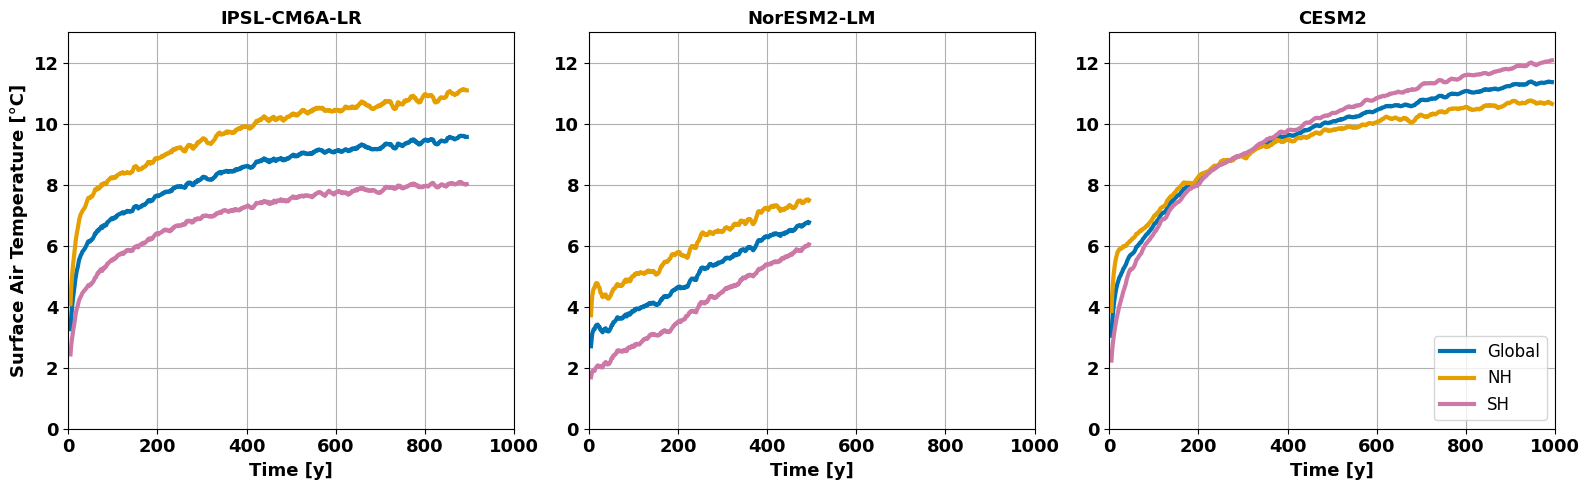

In [45]:
fig, axes = plt.subplots(
    nrows=1, ncols=3,
    figsize=(16, 5),
    sharex=True
)

# =========================
# Time axes
# =========================
time_cesm = np.arange(5, 994)
time_noresm = np.arange(5, 495)
time_ipsl = np.arange(5, 895)

# =========================
# ---- ROW 1: NorESM2-LM
# =========================
# piControl
ax = axes[0]
ax.plot(time_ipsl, roll_anom_tas_gl_ipsl, color = '#0072B2', lw=3)
ax.plot(time_ipsl, roll_anom_tas_nh_ipsl, color = '#E69F00', lw=3)
ax.plot(time_ipsl, roll_anom_tas_sh_ipsl, color = '#CC79A7', lw=3)
ax.set_title("IPSL-CM6A-LR", fontweight="bold", fontsize = 13)
ax.set_xlim(0, 1000)
ax.set_ylim(0, 13)
ax.set_ylabel("Surface Air Temperature [°C]", fontweight="bold", fontsize = 13)
ax.set_xlabel("Time [y]", fontweight="bold", fontsize = 13)
    # Make axis tick labels bold and larger
for tick in ax.get_xticklabels():
    tick.set_fontweight('bold')
    tick.set_fontsize(13)
for tick in ax.get_yticklabels():
    tick.set_fontweight('bold')
    tick.set_fontsize(13)
ax.grid()

# x4CO2
ax = axes[1]
ax.plot(time_noresm, roll_anom_tas_gl_noresm2, color = '#0072B2', lw=3)
ax.plot(time_noresm, roll_anom_tas_nh_noresm2, color = '#E69F00', lw=3)
ax.plot(time_noresm, roll_anom_tas_sh_noresm2, color = '#CC79A7', lw=3)
ax.set_title("NorESM2-LM", fontweight="bold", fontsize = 13)
ax.set_xlim(0, 1000)
ax.set_ylim(0, 13)
ax.set_xlabel("Time [y]", fontweight="bold", fontsize = 13)
    # Make axis tick labels bold and larger
for tick in ax.get_xticklabels():
    tick.set_fontweight('bold')
    tick.set_fontsize(13)
for tick in ax.get_yticklabels():
    tick.set_fontweight('bold')
    tick.set_fontsize(13)
ax.grid()

# anomalies
ax = axes[2]
ax.plot(time_cesm, roll_anom_tas_gl_cesm2, lw=3, color = '#0072B2', label="Global")
ax.plot(time_cesm, roll_anom_tas_nh_cesm2, lw=3, color = '#E69F00', label="NH")
ax.plot(time_cesm, roll_anom_tas_sh_cesm2, lw=3, color = '#CC79A7', label="SH")
ax.set_title("CESM2", fontweight="bold", fontsize = 13)
ax.set_xlim(0, 1000)
ax.set_ylim(0, 13)
ax.set_xlabel("Time [y]", fontweight="bold", fontsize = 13)

ax.grid()

    # Make axis tick labels bold and larger
for tick in ax.get_xticklabels():
    tick.set_fontweight('bold')
    tick.set_fontsize(13)
for tick in ax.get_yticklabels():
    tick.set_fontweight('bold')
    tick.set_fontsize(13)


# =========================
# Labels & legend
# =========================



ax.legend(loc="lower right", fontsize=12)

plt.tight_layout()
plt.show()

## **2. Global Contour Plots**

In [35]:
%%comment
data_piControl_list = [tas_noresm2_piControl, tas_ipsl_piControl, tas_cesm2_piControl]
titles = ["NorESM2-LM", "IPSL-CM6A-LR", "CESM2"]

fig = plt.figure(figsize=(18, 6))
gs = fig.add_gridspec(nrows=1, ncols=3, width_ratios=[1, 1, 1])

# Copy and modify cmap
cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad(color="white")

for i, data_piControl in enumerate(data_piControl_list):

    lon = data_piControl.lon.values
    lat = data_piControl.lat.values
    data = data_piControl.values

    # ---- FIX: wrap longitudes into -180..180 ----
    lon_wrapped = (((lon + 180) % 360) - 180)
    sort_idx = np.argsort(lon_wrapped)
    lon_wrapped = lon_wrapped[sort_idx]
    data = data[:, sort_idx]    # reorder data columns to match longitudes

    # Plot
    ax = fig.add_subplot(gs[0, i], projection=ccrs.Robinson())

    im = ax.pcolormesh(
        lon_wrapped,
        lat,
        data,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=-40, vmax=40
    )

    ax.coastlines()
    ax.set_title(titles[i], fontweight='bold')

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='gray', alpha=0.5, linestyle='--')

    gl.top_labels = False          # turn off top labels
    gl.right_labels = False        # turn off right labels
    gl.bottom_labels = False        # show lon labels
    gl.left_labels = True          # show lat labels

# ---- Horizontal colorbar spanning all panels ----
cbar_ax = fig.add_axes([0.15, 0.2, 0.7, 0.035])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Air Temperature values [°C]", fontweight='bold')

fig.suptitle("piControl mean over y0-30", fontsize=18, weight='bold', y=0.95)
plt.subplots_adjust(top=0.88, bottom=0.20, wspace=0.15)

plt.show()

In [36]:
%%comment
data_piControl_list = [tas_noresm2_470_500, tas_ipsl_470_500, tas_cesm2_470_500]
titles = ["NorESM2-LM", "IPSL-CM6A-LR", "CESM2"]

fig = plt.figure(figsize=(18, 6))
gs = fig.add_gridspec(nrows=1, ncols=3, width_ratios=[1, 1, 1])

# Copy and modify cmap
cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad(color="white")

for i, data_piControl in enumerate(data_piControl_list):

    lon = data_piControl.lon.values
    lat = data_piControl.lat.values
    data = data_piControl.values

    # ---- FIX: wrap longitudes into -180..180 ----
    lon_wrapped = (((lon + 180) % 360) - 180)
    sort_idx = np.argsort(lon_wrapped)
    lon_wrapped = lon_wrapped[sort_idx]
    data = data[:, sort_idx]    # reorder data columns to match longitudes

    # Plot
    ax = fig.add_subplot(gs[0, i], projection=ccrs.Robinson())

    im = ax.pcolormesh(
        lon_wrapped,
        lat,
        data,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=-40, vmax=40
    )

    ax.coastlines()
    ax.set_title(titles[i], fontweight='bold')

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='gray', alpha=0.5, linestyle='--')

    gl.top_labels = False          # turn off top labels
    gl.right_labels = False        # turn off right labels
    gl.bottom_labels = False        # show lon labels
    gl.left_labels = True          # show lat labels

# ---- Horizontal colorbar spanning all panels ----
cbar_ax = fig.add_axes([0.15, 0.2, 0.7, 0.035])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Air Temperature values [°C]", fontweight='bold')

fig.suptitle("abrupt-4xCO2 mean over y470-500", fontsize=18, weight='bold', y=0.95)
plt.subplots_adjust(top=0.88, bottom=0.20, wspace=0.15)

plt.show()

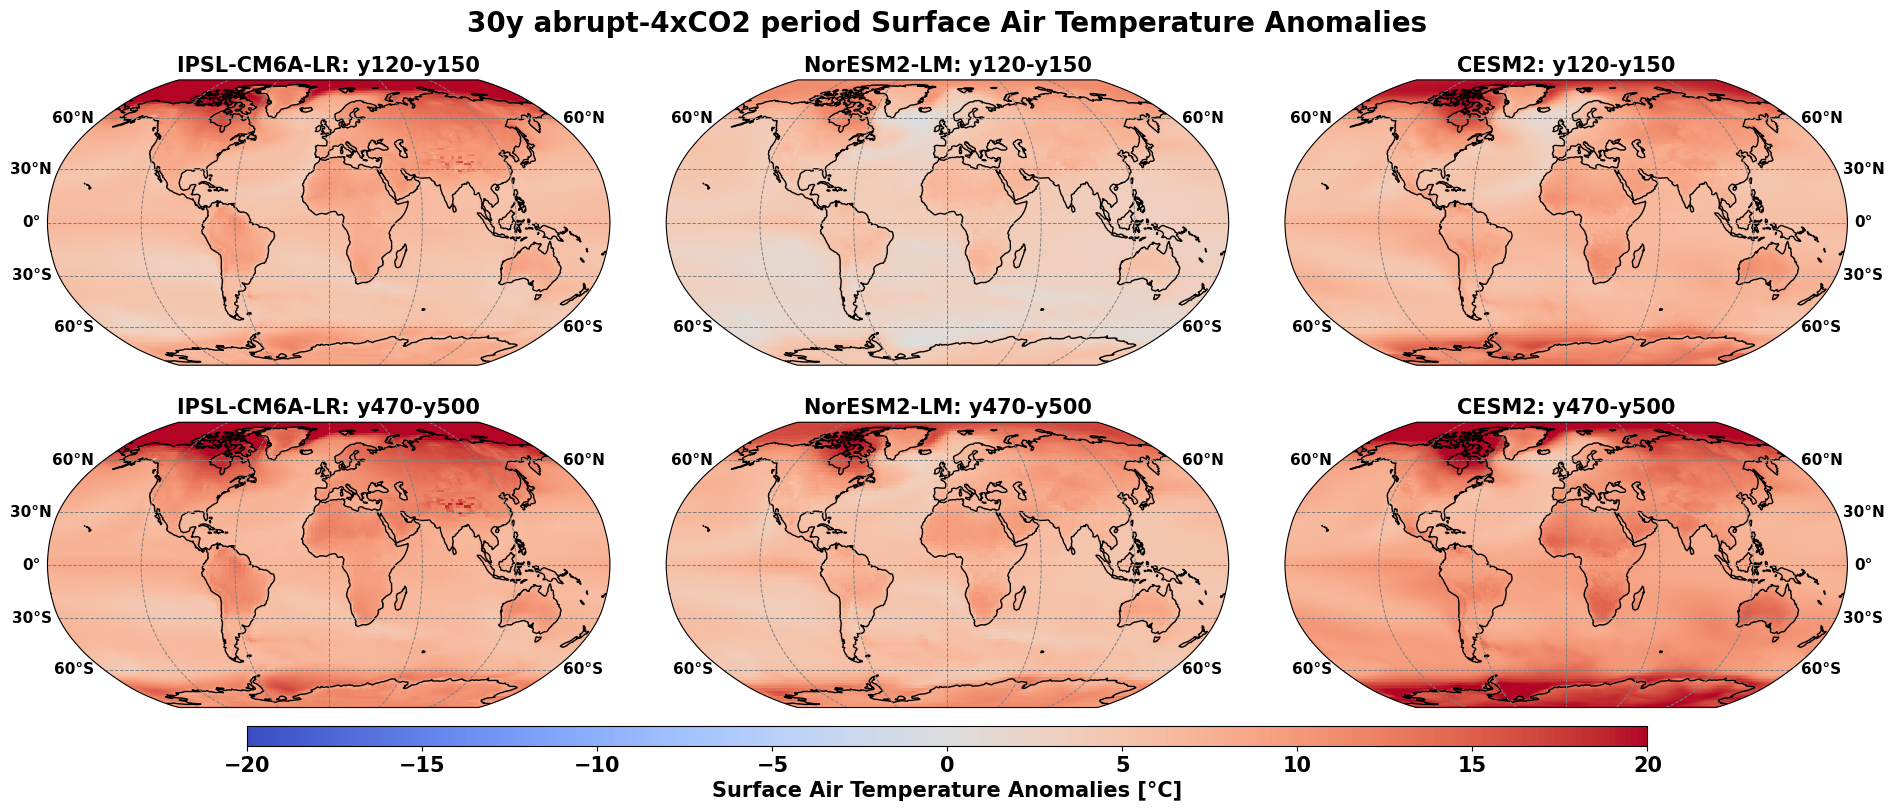

In [54]:
# ---- DATASETS ----

noresm_datasets = [
    (tas_noresm2_120_150 - tas_noresm2_piControl,  "NorESM2-LM: y120-y150"),
    (tas_noresm2_470_500 - tas_noresm2_piControl,  "NorESM2-LM: y470-y500"),
]

ipsl_datasets = [
    (tas_ipsl_120_150 - tas_ipsl_piControl, "IPSL-CM6A-LR: y120-y150"),
    (tas_ipsl_470_500 - tas_ipsl_piControl, "IPSL-CM6A-LR: y470-y500"),
]

cesm_datasets = [
    (tas_cesm2_120_150 - tas_cesm2_piControl, "CESM2: y120-y150"),
    (tas_cesm2_470_500 - tas_cesm2_piControl, "CESM2: y470-y500"),]

all_groups = [ipsl_datasets, noresm_datasets, cesm_datasets]

# Count how many rows needed for each column
col_rows = [len(ipsl_datasets), len(noresm_datasets), len(cesm_datasets)]
max_rows = max(col_rows)

# ---- FIGURE & COLORBAR ----

fig = plt.figure(figsize=(20, 8))
gs = fig.add_gridspec(
    nrows=max_rows, ncols=3,
    height_ratios=[1]*max_rows,   # equal row spacing
    width_ratios=[1, 1, 1]
)

cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad(color="white")

# ---- FUNCTION: longitude wrapping ----
def wrap_lon(lon, data):
    lon_wrapped = (((lon + 180) % 360) - 180)
    s = np.argsort(lon_wrapped)
    return lon_wrapped[s], data[:, s]

# ---- PLOTTING LOOP ----

for col, group in enumerate(all_groups):          # 3 columns
    n_panels = len(group)
    if col == 0:  # first column
        offset = 0
    else:
        offset = (max_rows - n_panels) // 2

    for k, (data_anom, panel_title) in enumerate(group):

        lon = data_anom.lon.values
        lat = data_anom.lat.values
        data = data_anom.values

        # wrap longitudes to -180..180
        lon_w, data_w = wrap_lon(lon, data)

        row = offset + k

        ax = fig.add_subplot(gs[row, col], projection=ccrs.Robinson())

        im = ax.pcolormesh(
            lon_w,
            lat,
            data_w,
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            vmin=-20, vmax=20
        )

        ax.coastlines()
        ax.set_title(panel_title, fontsize=15, fontweight='bold')

        gl = ax.gridlines(
            crs=ccrs.PlateCarree(),
            draw_labels=True,
            linewidth=0.7,
            color='gray',
            linestyle='--',
            x_inline=False,   # prevent label placement across plot edges
            y_inline=False
        )

        # ---- Only show left labels for first column, right labels for last column ----
        if col == 0:  # first column
            gl.left_labels = True
            gl.right_labels = False
        elif col == 2:  # last column
            gl.left_labels = False
            gl.right_labels = True
        else:  # middle column
            gl.left_labels = False
            gl.right_labels = False

        # Turn off top and bottom labels everywhere
        gl.top_labels = False
        gl.bottom_labels = False

        # ---- Bold + fontsize 11 for labels ----
        gl.xlabel_style = {'fontsize': 11, 'fontweight': 'bold'}
        gl.ylabel_style = {'fontsize': 11, 'fontweight': 'bold'}

        # ---- Horizontal colorbar ----
cbar_ax = fig.add_axes([0.15, 0.06, 0.7, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label("Surface Air Temperature Anomalies [°C]", fontweight='bold', fontsize = 15)
cbar.ax.tick_params(labelsize=15)  # make numbers bigger

# make numbers bold
for t in cbar.ax.get_xticklabels():
    t.set_fontweight('bold')
    
# ---- Layout adjustments ----
fig.suptitle("30y abrupt-4xCO2 period Surface Air Temperature Anomalies", fontsize=20, weight='bold')

plt.subplots_adjust(
    left=0.05,
    right=0.95,
    top=0.9,
    bottom=0.10,
    wspace=0.10,
    hspace=0.15
)

plt.show()

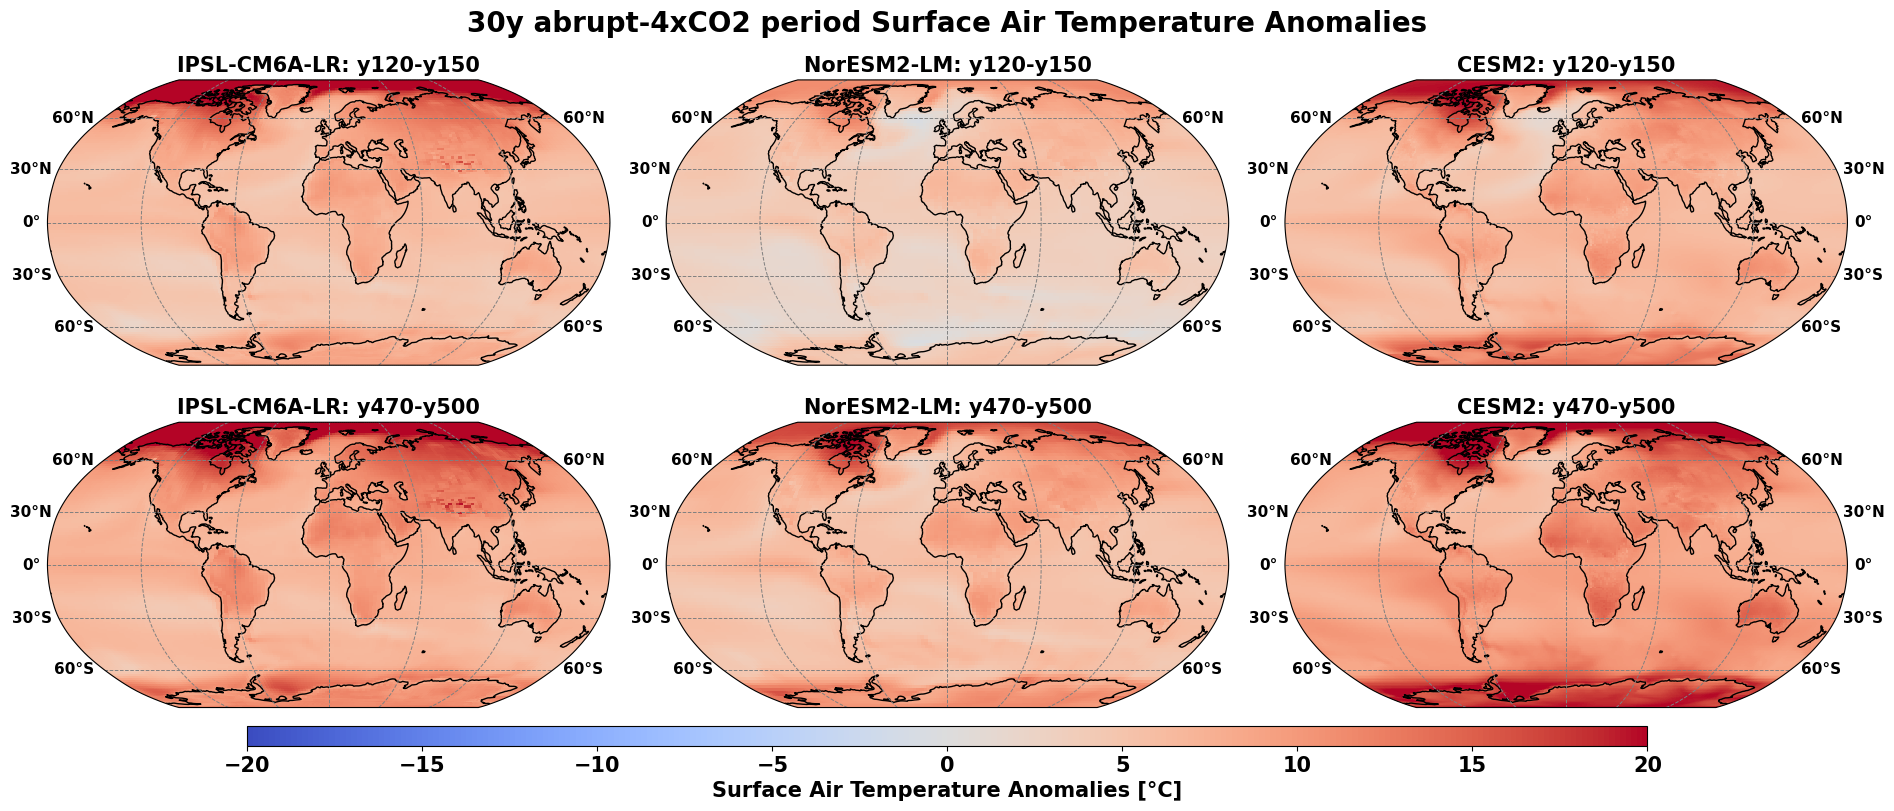

In [58]:
# ---- DATASETS ----

noresm_datasets = [
    (tas_noresm2_120_150 - tas_noresm2_piControl,  "NorESM2-LM: y120-y150"),
    (tas_noresm2_470_500 - tas_noresm2_piControl,  "NorESM2-LM: y470-y500"),
]

ipsl_datasets = [
    (tas_ipsl_120_150 - tas_ipsl_piControl, "IPSL-CM6A-LR: y120-y150"),
    (tas_ipsl_470_500 - tas_ipsl_piControl, "IPSL-CM6A-LR: y470-y500"),
]

cesm_datasets = [
    (tas_cesm2_120_150 - tas_cesm2_piControl, "CESM2: y120-y150"),
    (tas_cesm2_470_500 - tas_cesm2_piControl, "CESM2: y470-y500"),
]

all_groups = [ipsl_datasets, noresm_datasets, cesm_datasets]

# Count how many rows needed for each column
col_rows = [len(ipsl_datasets), len(noresm_datasets), len(cesm_datasets)]
max_rows = max(col_rows)

# ---- FIGURE & COLORBAR ----

fig = plt.figure(figsize=(20, 8))
gs = fig.add_gridspec(
    nrows=max_rows, ncols=3,
    height_ratios=[1]*max_rows,
    width_ratios=[1, 1, 1]
)

cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad(color="white")

# ---- FUNCTION: longitude wrapping ----
def wrap_lon(lon, data):
    lon_wrapped = (((lon + 180) % 360) - 180)
    s = np.argsort(lon_wrapped)
    return lon_wrapped[s], data[:, s]

# ---- PLOTTING LOOP ----
for col, group in enumerate(all_groups):  # 3 columns
    n_panels = len(group)
    offset = (max_rows - n_panels) // 2 if col != 0 else 0  # center columns except first

    for k, (data_anom, panel_title) in enumerate(group):
        lon = data_anom.lon.values
        lat = data_anom.lat.values
        data = data_anom.values

        lon_w, data_w = wrap_lon(lon, data)

        row = offset + k
        ax = fig.add_subplot(gs[row, col], projection=ccrs.Robinson())

        im = ax.pcolormesh(
            lon_w,
            lat,
            data_w,
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            vmin=-20, vmax=20
        )

        ax.coastlines()
        ax.set_title(panel_title, fontsize=15, fontweight='bold')

        # ---- Gridlines ----
        gl = ax.gridlines(
            crs=ccrs.PlateCarree(),
            draw_labels=True,
            linewidth=0.7,
            color='gray',
            linestyle='--',
            x_inline=False,
            y_inline=False
        )

        # Turn off all labels by default
        gl.top_labels = False
        gl.bottom_labels = False
        gl.left_labels = True
        gl.right_labels = False

        # Only show left labels for first column and right labels for last column
#        if col == 0:
#            gl.left_labels = True
        gl.ylabel_style = {'fontsize': 11, 'fontweight': 'bold'}
        if col == 2:
            gl.right_labels = True
            gl.ylabel_style = {'fontsize': 11, 'fontweight': 'bold'}

# ---- Horizontal colorbar ----
cbar_ax = fig.add_axes([0.15, 0.06, 0.7, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label("Surface Air Temperature Anomalies [°C]", fontweight='bold', fontsize=15)
cbar.ax.tick_params(labelsize=15)
for t in cbar.ax.get_xticklabels():
    t.set_fontweight('bold')

# ---- Layout adjustments ----
fig.suptitle("30y abrupt-4xCO2 period Surface Air Temperature Anomalies", fontsize=20, weight='bold')

plt.subplots_adjust(
    left=0.05,
    right=0.95,
    top=0.9,
    bottom=0.10,
    wspace=0.10,
    hspace=0.15
)

plt.show()